In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ── Define stock universe ──────────────────────────────────────────────────────
tickers = {
    'RELIANCE': 'RELIANCE.NS',
    'HDFCBANK': 'HDFCBANK.NS',
    'INFY':     'INFY.NS',
    'SUNPHARMA':'SUNPHARMA.NS',
    'MARUTI':   'MARUTI.NS',
    'ITC':      'ITC.NS',
    'TATASTEEL':'TATASTEEL.NS'
}

# ── Fetch all data ─────────────────────────────────────────────────────────────
raw_data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start="2021-01-01", end="2025-12-31", interval="1d", auto_adjust=True)
    raw_data[name] = df
    print(f"{name}: {len(df)} rows fetched")

[*********************100%***********************]  1 of 1 completed


RELIANCE: 1235 rows fetched


[*********************100%***********************]  1 of 1 completed


HDFCBANK: 1235 rows fetched


[*********************100%***********************]  1 of 1 completed


...

MARUTI: 1235 rows fetched


[*********************100%***********************]  1 of 1 completed


ITC: 1235 rows fetched


[*********************100%***********************]  1 of 1 completed

TATASTEEL: 1235 rows fetched


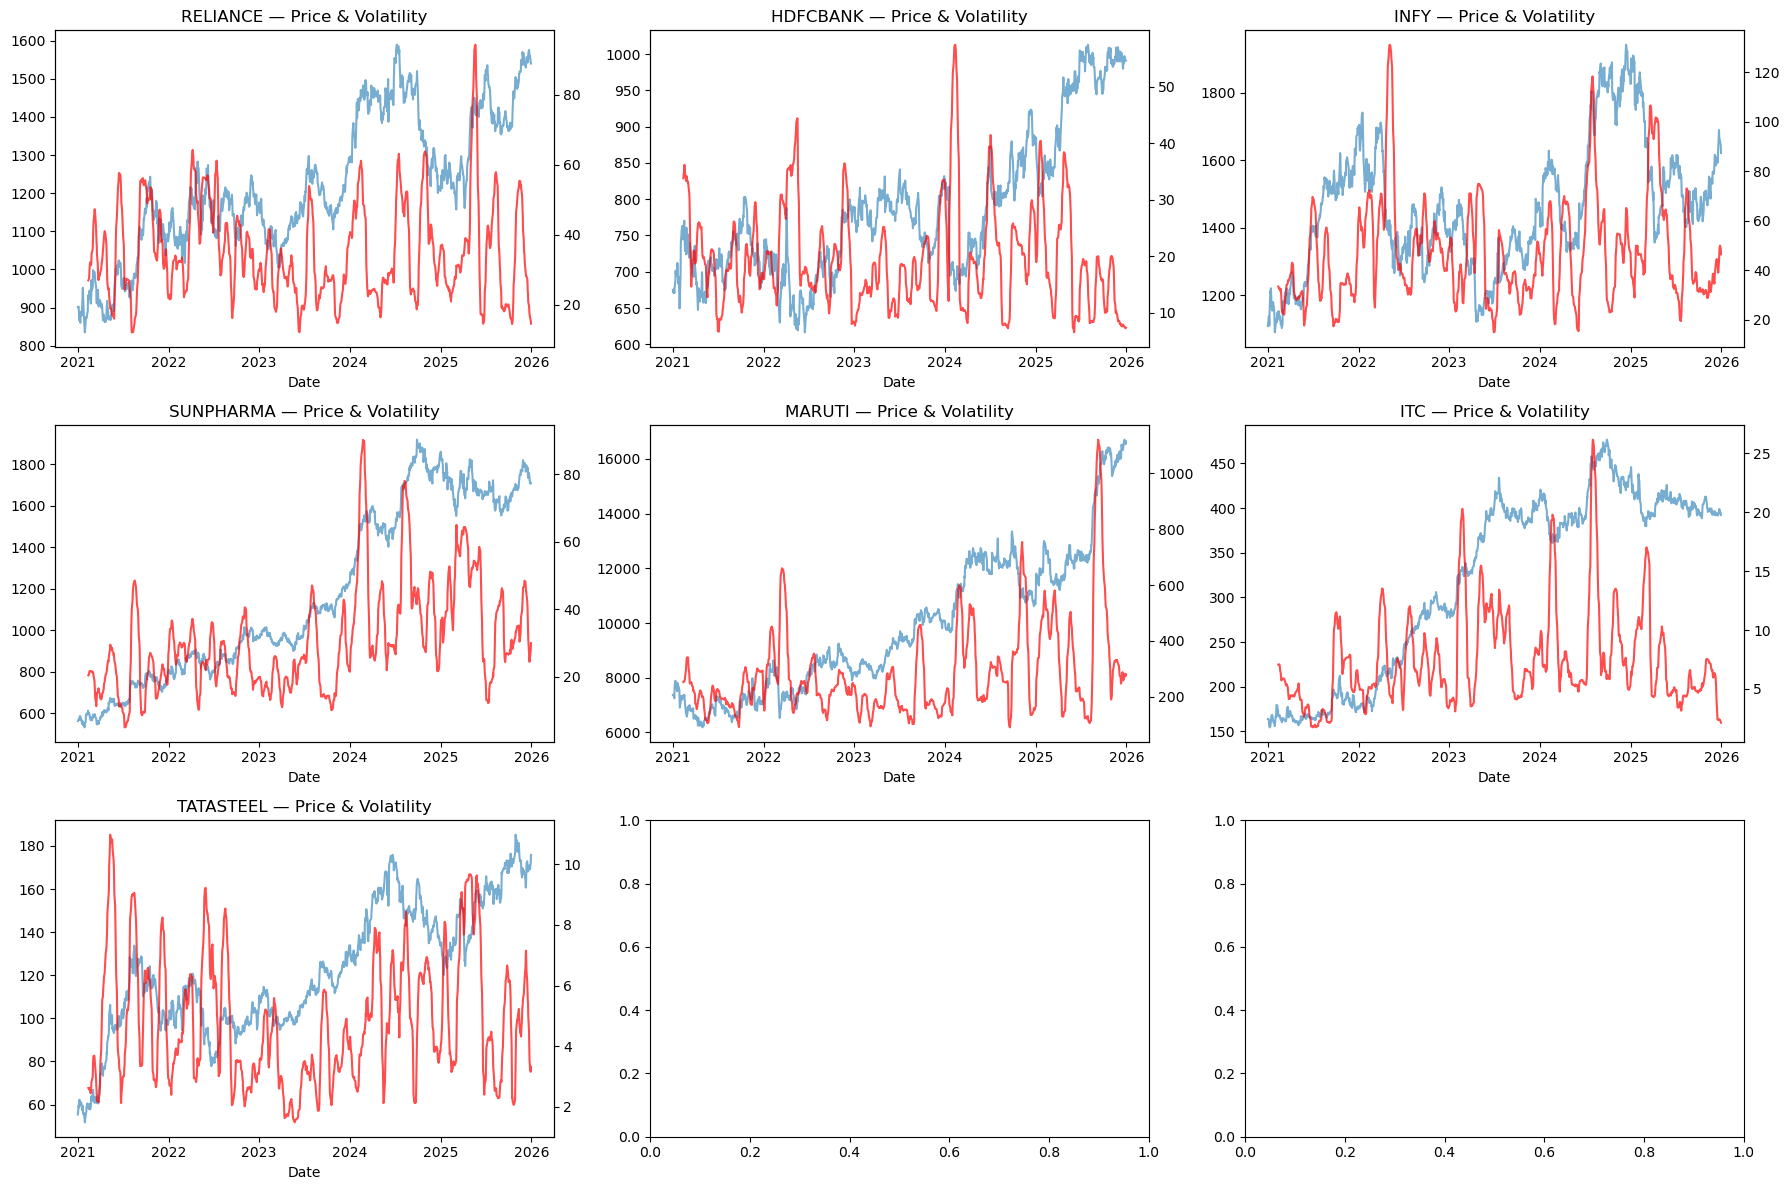

In [2]:
# ── Justification 1: Rolling Standard Deviation (Volatility Profiles) ─────────
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, df) in enumerate(raw_data.items()):
    close = df['Close'].squeeze()
    rolling_std = close.rolling(window=30).std()
    axes[idx].plot(close, label='Close Price', alpha=0.6)
    ax2 = axes[idx].twinx()
    ax2.plot(rolling_std, color='red', label='30-day Rolling Std', alpha=0.7)
    axes[idx].set_title(f'{name} — Price & Volatility')
    axes[idx].set_xlabel('Date')

plt.tight_layout()
plt.savefig('task1_rolling_std.png', dpi=150)
plt.show()

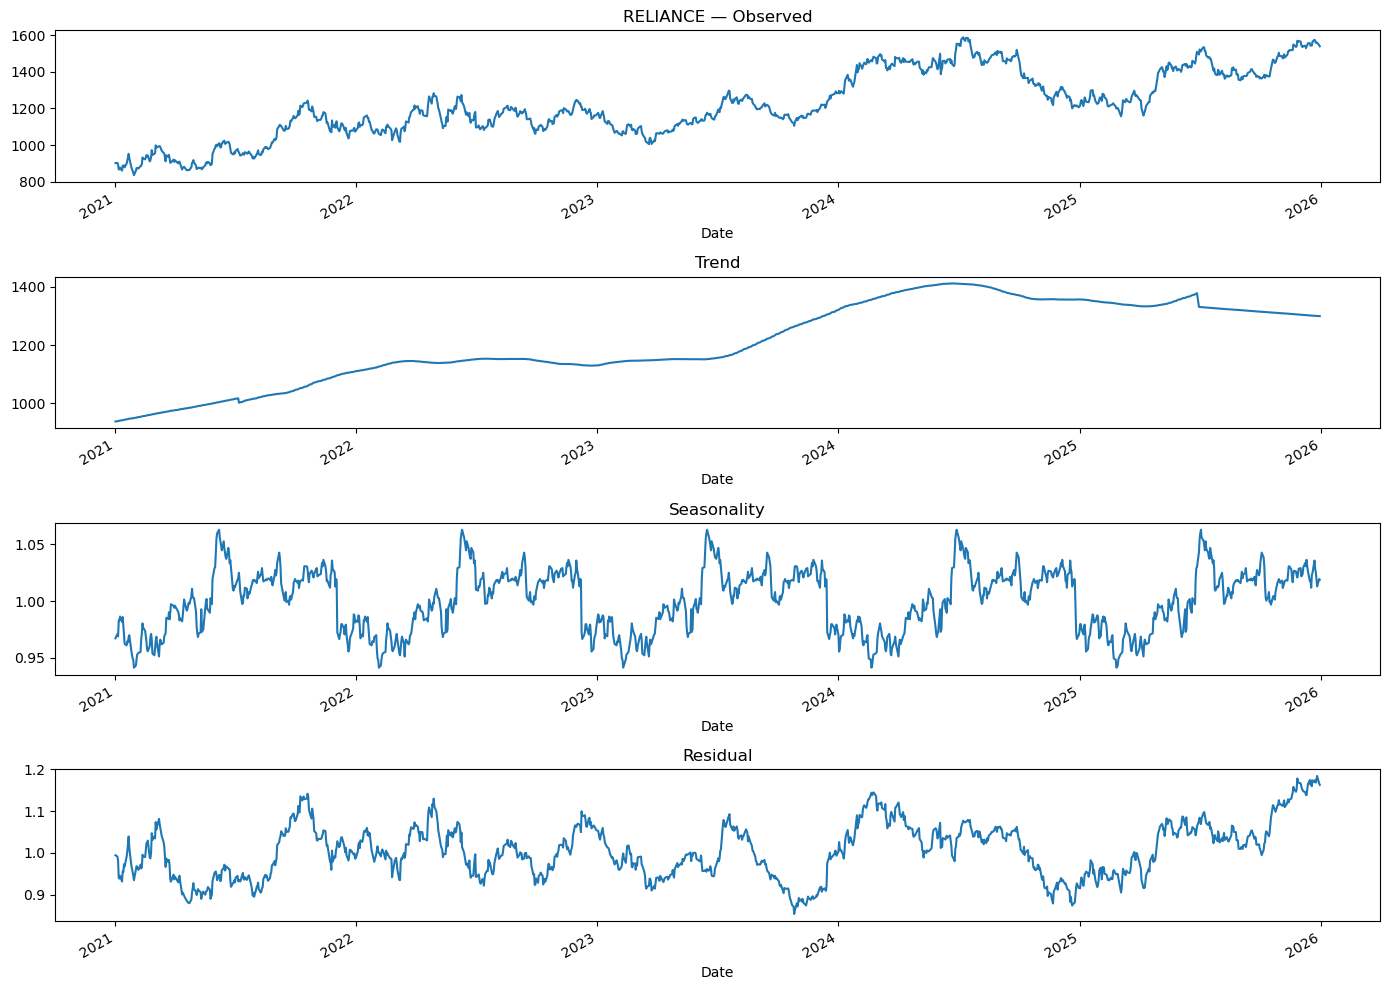

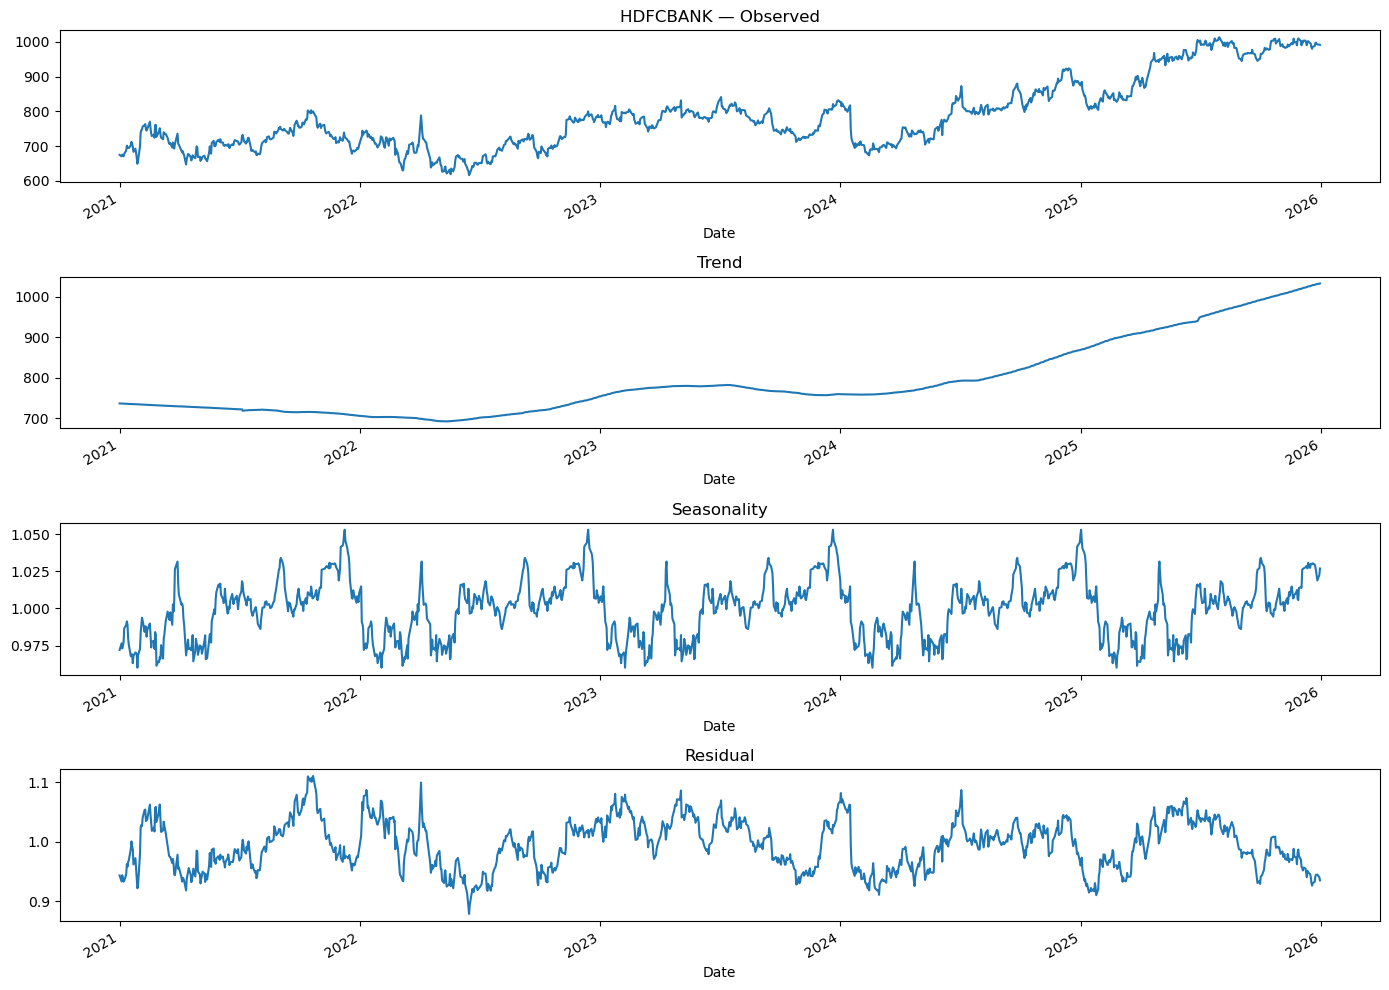

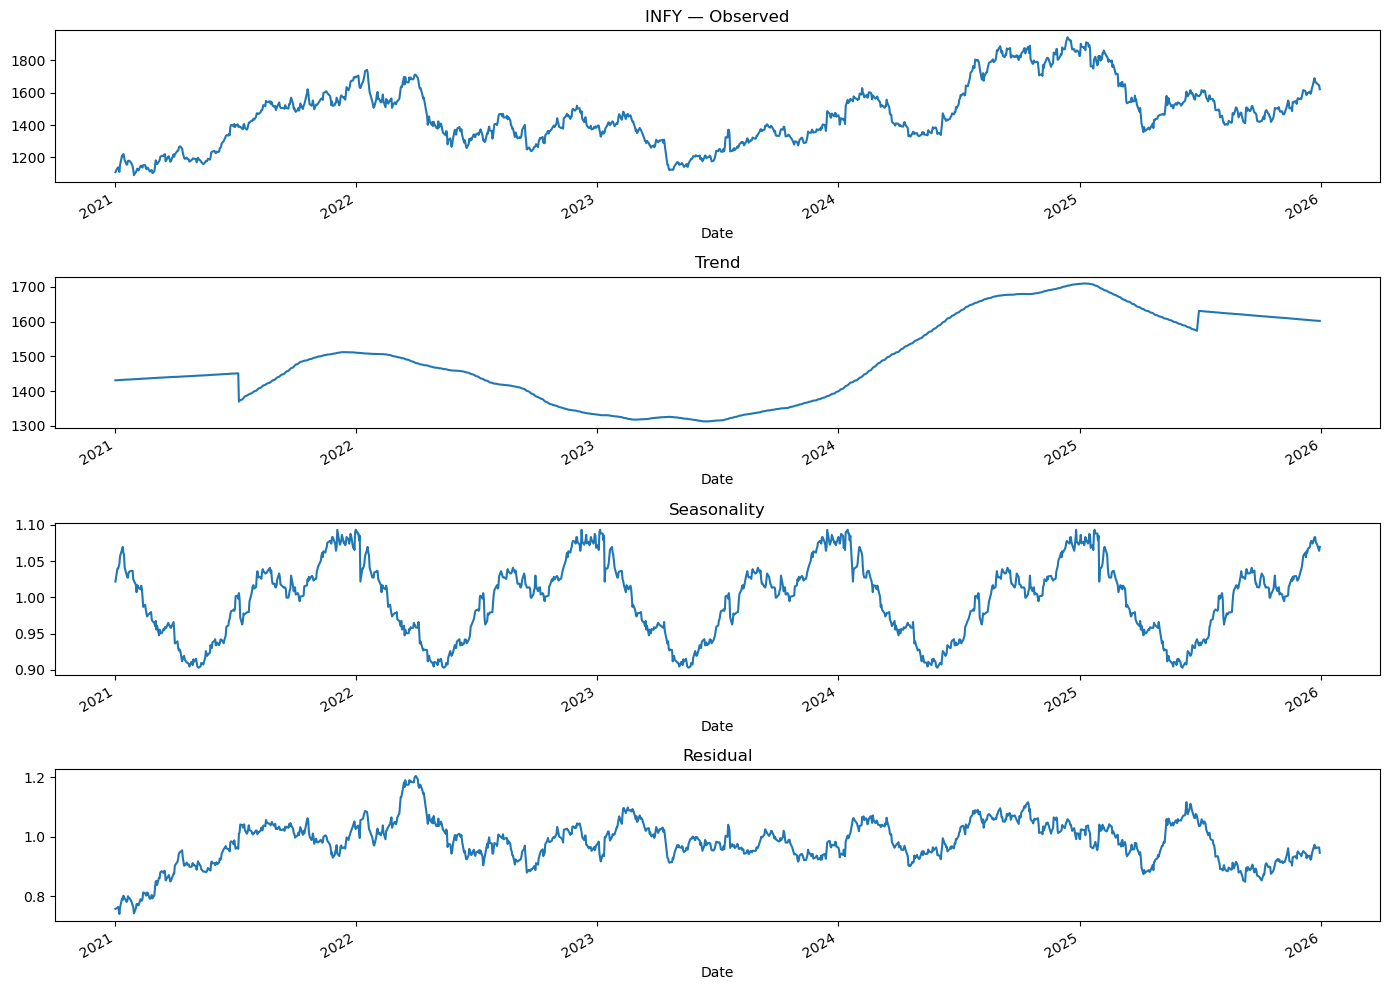

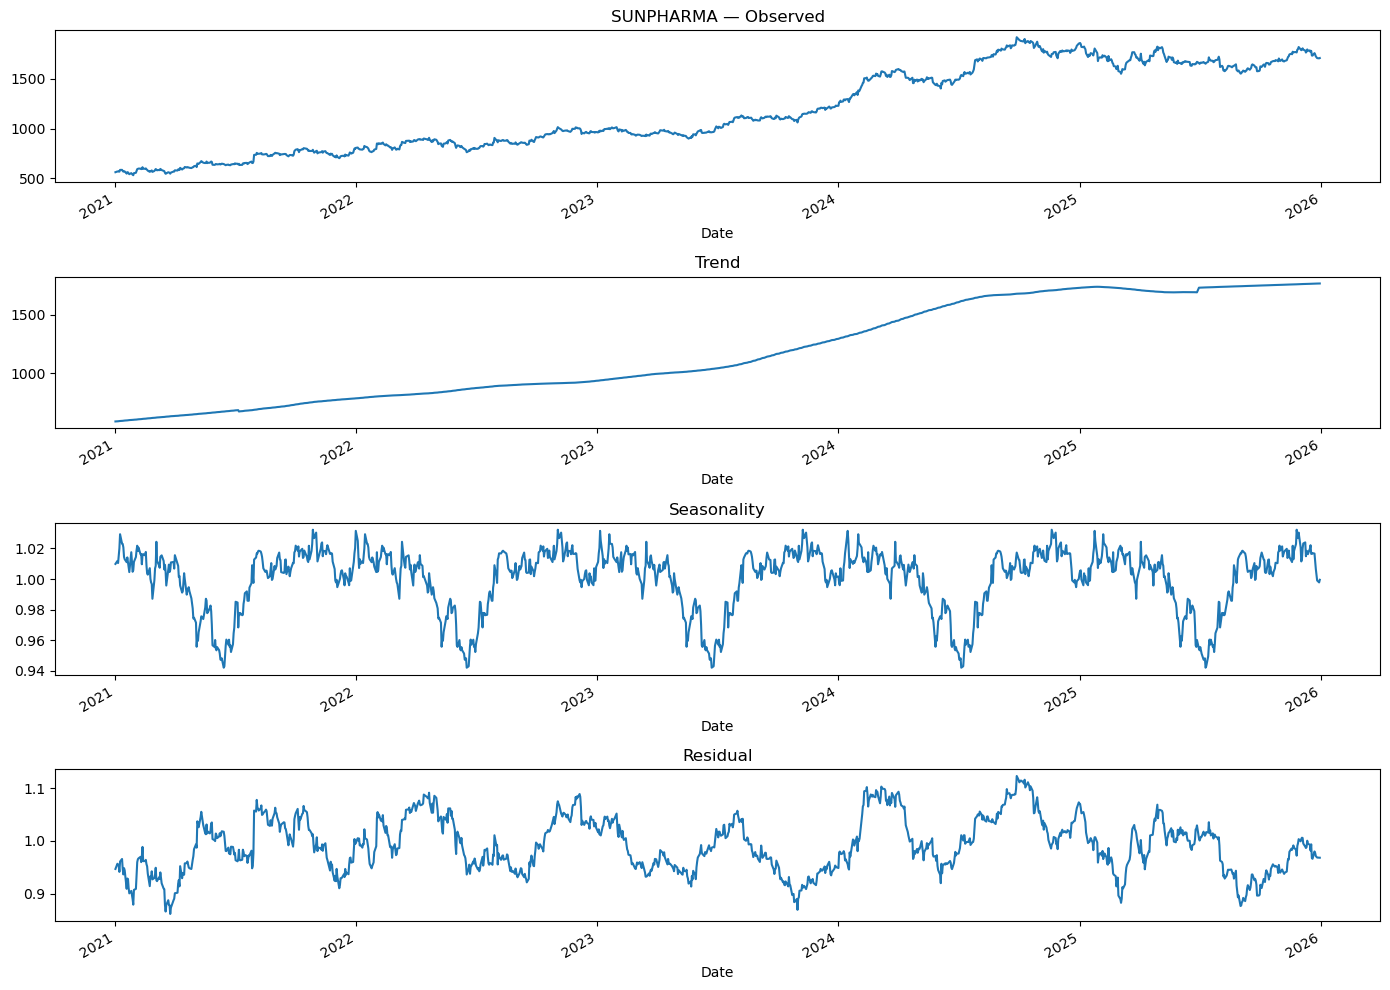

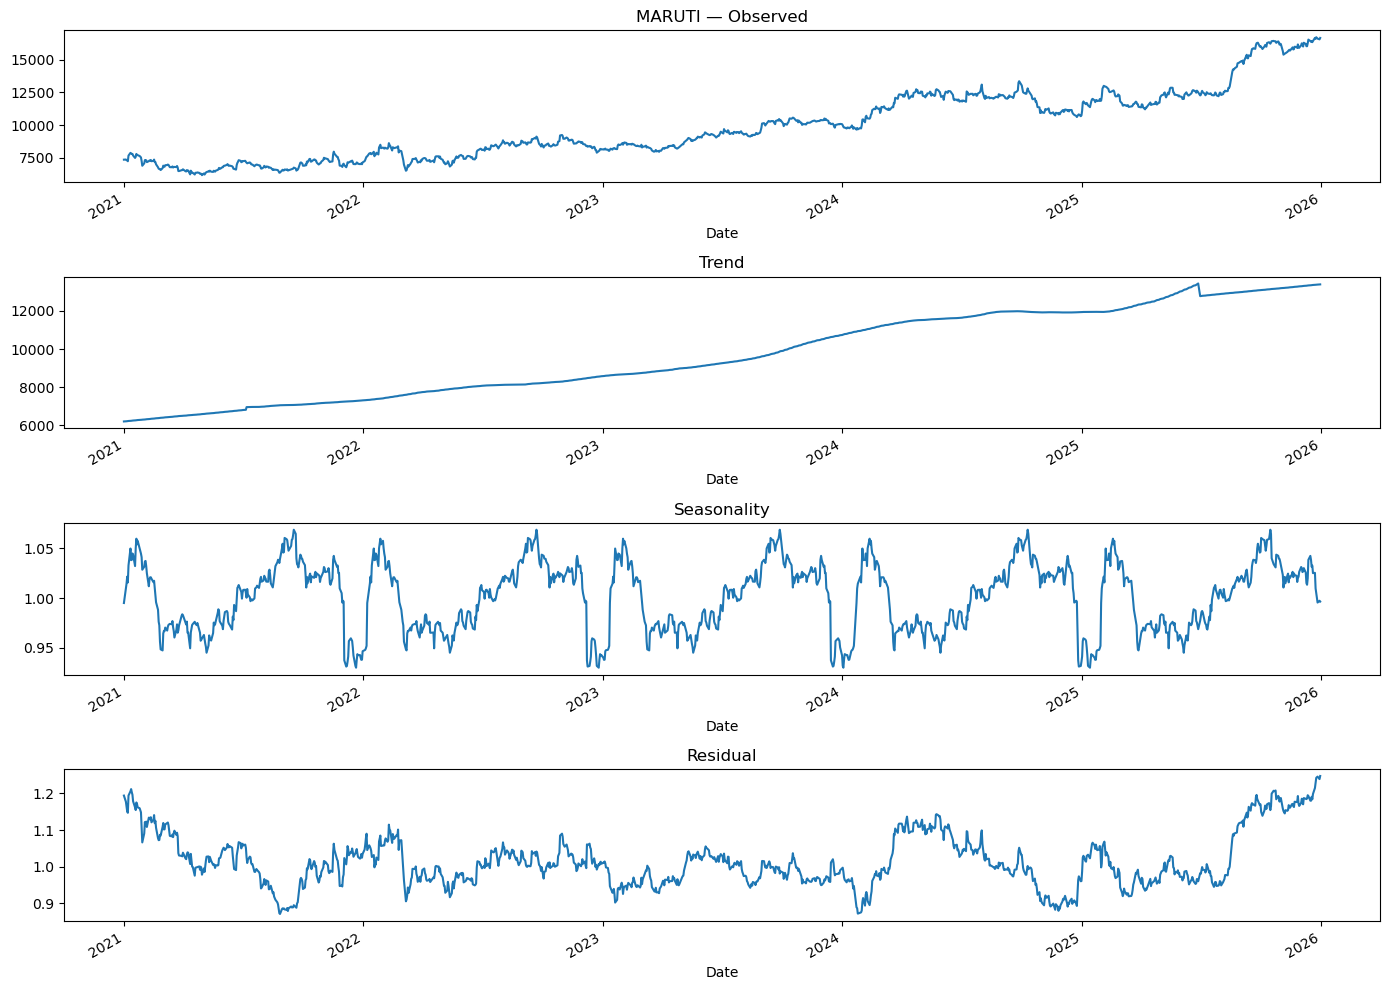

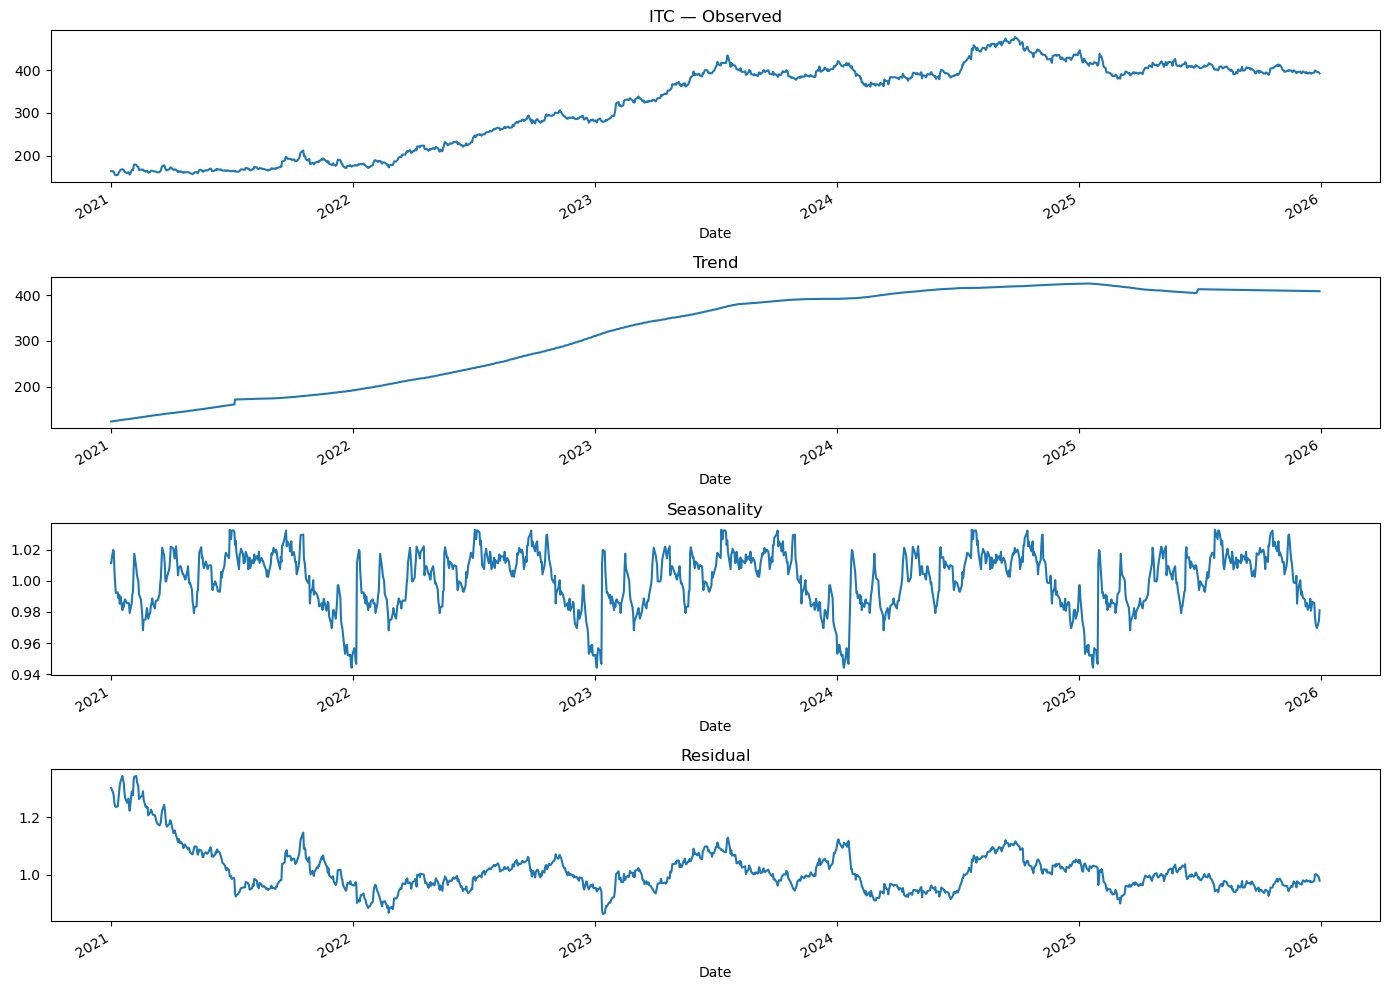

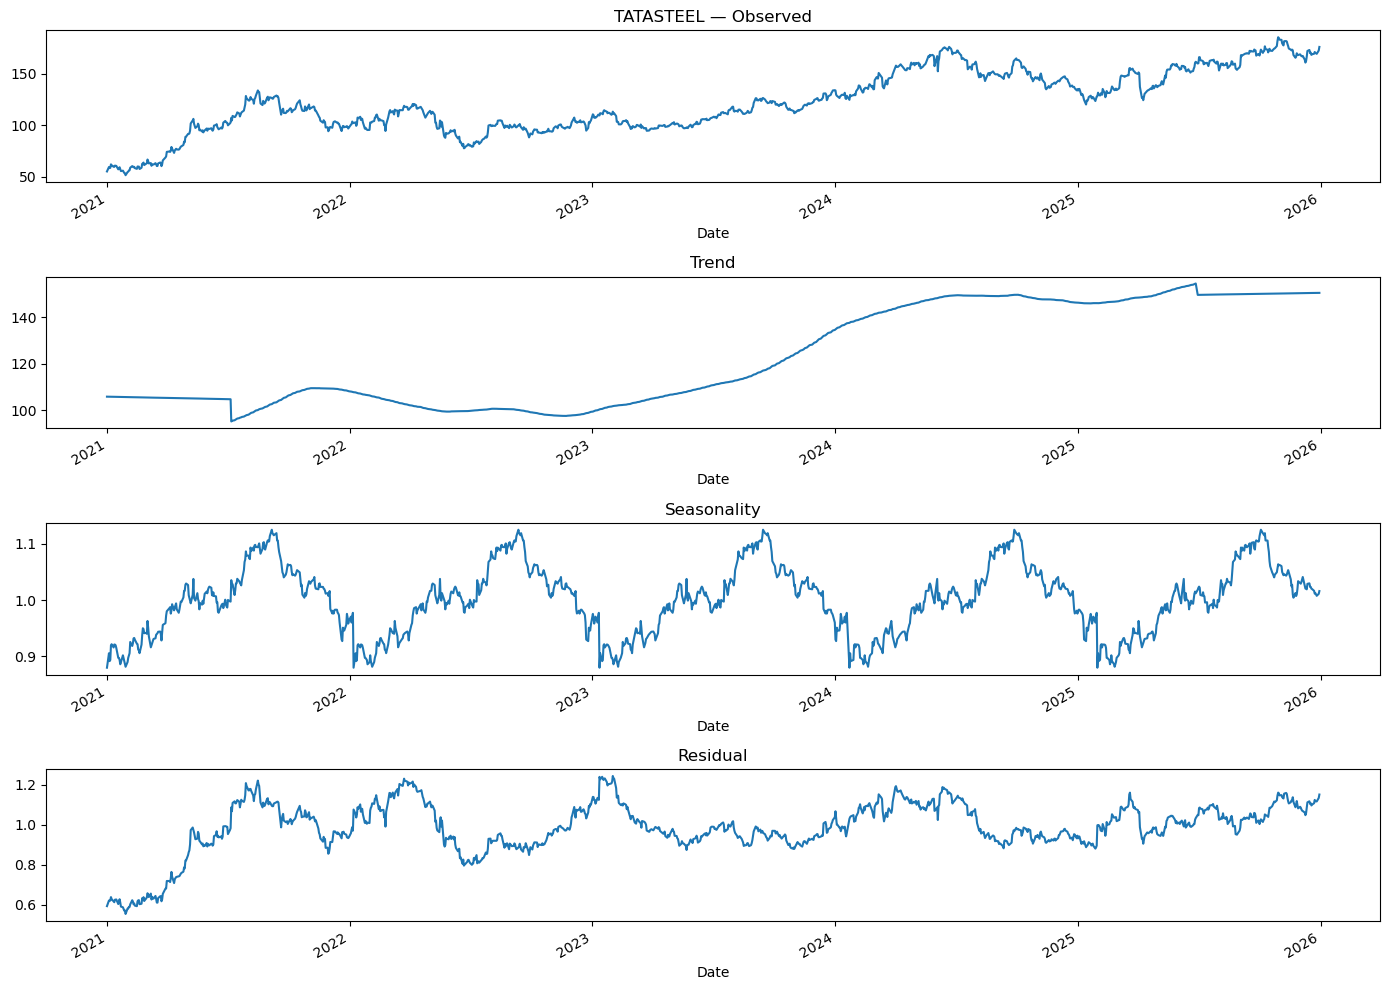

In [3]:
# ── Justification 2: Seasonal Decomposition (Trend Strength) ──────────────────
for name, df in raw_data.items():
    close = df['Close'].squeeze().dropna()
    # Need at least 2 full periods; use period=252 (trading days/year)
    decomp = seasonal_decompose(close, model='multiplicative', period=252, extrapolate_trend='freq')
    
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10))
    decomp.observed.plot(ax=ax1, title=f'{name} — Observed')
    decomp.trend.plot(ax=ax2, title='Trend')
    decomp.seasonal.plot(ax=ax3, title='Seasonality')
    decomp.resid.plot(ax=ax4, title='Residual')
    plt.tight_layout()
    plt.savefig(f'task1_decomp_{name}.png', dpi=100)
    plt.show()

-> RELIANCE: Strong upward trend; moderate volatility → strong trend candidate
-> HDFCBANK: Banking sector momentum; lower volatility → stable allocation
-> INFY: IT sector; high rolling std in 2022–2023 → interesting volatility profile
-> SUNPHARMA: Defensive sector; low correlation with cyclicals
-> MARUTI: Auto recovery cycle visible in trend decomposition
-> ITC: FMCG; consistent upward trend post-2022; low seasonal noise
-> TATASTEEL: High volatility, cyclical → diversification through metals

In [4]:
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler

# ── Step 1: Extract Close prices into a single DataFrame ──────────────────────
close_prices = pd.DataFrame({
    name: df['Close'].squeeze() for name, df in raw_data.items()
})
print("Shape before cleaning:", close_prices.shape)
print("Missing values:\n", close_prices.isnull().sum())

# ── Step 2: Handle missing values ─────────────────────────────────────────────
# Forward fill first, then backward fill for any leading NaNs
close_prices = close_prices.ffill().bfill()
print("Missing after fill:", close_prices.isnull().sum().sum())

# ── Step 3: ADF Stationarity Test ─────────────────────────────────────────────
def adf_test(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]
    is_stationary = p_value < 0.05
    print(f"{name:12s} | ADF Stat: {result[0]:8.4f} | p-value: {p_value:.4f} | "
          f"Stationary: {'YES' if is_stationary else 'NO'}")
    return is_stationary

print("=" * 65)
print("ADF Test on Raw Price Series:")
print("=" * 65)
stationarity = {}
for col in close_prices.columns:
    stationarity[col] = adf_test(close_prices[col], col)

# ── Step 4: Apply differencing for non-stationary series ──────────────────────
# (Almost all raw stock price series will be non-stationary)
returns = close_prices.pct_change().dropna()  # Log returns also acceptable
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

print("\nADF Test on Log Returns (differenced):")
print("=" * 65)
for col in log_returns.columns:
    adf_test(log_returns[col], col)

# ── Step 5: Train / Test Split ────────────────────────────────────────────────
# Training: Jan 2021 – Jun 2025
# Testing:  Jul 2025 – Dec 2025

train_end   = '2025-06-30'
test_start  = '2025-07-01'

train_prices = close_prices.loc[:train_end]
test_prices  = close_prices.loc[test_start:]

print(f"Training set: {train_prices.index[0].date()} → {train_prices.index[-1].date()} ({len(train_prices)} days)")
print(f"Testing set:  {test_prices.index[0].date()} → {test_prices.index[-1].date()} ({len(test_prices)} days)")

# ── Step 6: Normalize data for LSTM (per stock) ───────────────────────────────
scalers = {}
train_scaled = pd.DataFrame(index=train_prices.index)
test_scaled  = pd.DataFrame(index=test_prices.index)

for col in close_prices.columns:
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled[col] = scaler.fit_transform(train_prices[[col]]).flatten()
    test_scaled[col]  = scaler.transform(test_prices[[col]]).flatten()
    scalers[col] = scaler  # Save for inverse transform later

print("Scaling complete. Sample of scaled training data:")
print(train_scaled.head())

Shape before cleaning: (1235, 7)
Missing values:
 RELIANCE     0
HDFCBANK     0
INFY         0
SUNPHARMA    0
MARUTI       0
ITC          0
TATASTEEL    0
dtype: int64
Missing after fill: 0
ADF Test on Raw Price Series:
RELIANCE     | ADF Stat:  -1.6857 | p-value: 0.4385 | Stationary: NO
HDFCBANK     | ADF Stat:  -1.3959 | p-value: 0.5843 | Stationary: NO
INFY         | ADF Stat:  -2.3999 | p-value: 0.1418 | Stationary: NO
SUNPHARMA    | ADF Stat:  -0.8476 | p-value: 0.8047 | Stationary: NO
MARUTI       | ADF Stat:   0.4875 | p-value: 0.9845 | Stationary: NO
ITC          | ADF Stat:  -1.3689 | p-value: 0.5971 | Stationary: NO
TATASTEEL    | ADF Stat:  -1.7539 | p-value: 0.4036 | Stationary: NO

ADF Test on Log Returns (differenced):
RELIANCE     | ADF Stat: -21.4069 | p-value: 0.0000 | Stationary: YES
HDFCBANK     | ADF Stat: -14.0585 | p-value: 0.0000 | Stationary: YES
INFY         | ADF Stat: -33.5387 | p-value: 0.0000 | Stationary: YES
SUNPHARMA    | ADF Stat: -37.1367 | p-value: 0.

In [5]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools

def fit_arima(series, stock_name, forecast_steps=5):
    """
    Auto-selects best ARIMA order using AIC.
    Returns model, forecast, and evaluation metrics.
    """
    # Grid search over p, d, q
    best_aic = np.inf
    best_order = (1, 1, 1)
    
    for p in range(0, 4):
        for d in range(1, 3):
            for q in range(0, 4):
                try:
                    model = ARIMA(series, order=(p, d, q))
                    result = model.fit()
                    if result.aic < best_aic:
                        best_aic = result.aic
                        best_order = (p, d, q)
                except:
                    continue
    
    print(f"  {stock_name}: Best ARIMA order = {best_order}, AIC = {best_aic:.2f}")
    
    # Fit final model
    final_model = ARIMA(series, order=best_order).fit()
    
    # Forecast
    forecast_result = final_model.forecast(steps=forecast_steps)
    conf_int = final_model.get_forecast(steps=forecast_steps).conf_int()
    
    return final_model, forecast_result, conf_int, best_order


# ── Run ARIMA for all stocks ───────────────────────────────────────────────────
arima_forecasts = {}
arima_metrics   = {}

for stock in close_prices.columns:
    print(f"\nFitting ARIMA for {stock}...")
    train_series = train_prices[stock].dropna()
    test_series  = test_prices[stock].dropna()
    
    model, forecast, conf_int, order = fit_arima(train_series, stock, forecast_steps=len(test_series))
    
    # Evaluation on test set
    # Re-forecast for entire test period
    forecast_test = model.forecast(steps=len(test_series))
    
    mape = np.mean(np.abs((test_series.values - forecast_test.values) / test_series.values)) * 100
    rmse = np.sqrt(np.mean((test_series.values - forecast_test.values) ** 2))
    
    # Directional accuracy
    actual_dir   = np.sign(np.diff(test_series.values))
    forecast_dir = np.sign(np.diff(forecast_test.values))
    dir_acc = np.mean(actual_dir == forecast_dir) * 100
    
    arima_forecasts[stock] = {
        'model': model,
        'test_forecast': forecast_test,
        'next_2_days': model.forecast(steps=2),  # The key deliverable
        'conf_int': conf_int,
        'order': order
    }
    arima_metrics[stock] = {'MAPE': mape, 'RMSE': rmse, 'Dir_Acc': dir_acc}
    print(f"  MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | Dir Acc: {dir_acc:.1f}%")


Fitting ARIMA for RELIANCE...
  RELIANCE: Best ARIMA order = (2, 1, 2), AIC = 9497.44
  MAPE: 5.01% | RMSE: 82.11 | Dir Acc: 54.8%

Fitting ARIMA for HDFCBANK...
  HDFCBANK: Best ARIMA order = (2, 1, 2), AIC = 8354.54
  MAPE: 1.44% | RMSE: 19.50 | Dir Acc: 47.6%

Fitting ARIMA for INFY...
  INFY: Best ARIMA order = (0, 1, 0), AIC = 10059.55
  MAPE: 5.41% | RMSE: 93.74 | Dir Acc: 0.8%

Fitting ARIMA for SUNPHARMA...
  SUNPHARMA: Best ARIMA order = (2, 2, 3), AIC = 9176.50
  MAPE: 3.51% | RMSE: 71.02 | Dir Acc: 58.1%

Fitting ARIMA for MARUTI...
  MARUTI: Best ARIMA order = (0, 2, 2), AIC = 14047.77
  MAPE: 15.14% | RMSE: 2786.81 | Dir Acc: 55.6%

Fitting ARIMA for ITC...
  ITC: Best ARIMA order = (3, 1, 3), AIC = 6187.76
  MAPE: 2.16% | RMSE: 10.06 | Dir Acc: 50.8%

Fitting ARIMA for TATASTEEL...
  TATASTEEL: Best ARIMA order = (0, 1, 0), AIC = 5113.93
  MAPE: 4.99% | RMSE: 10.64 | Dir Acc: 0.0%


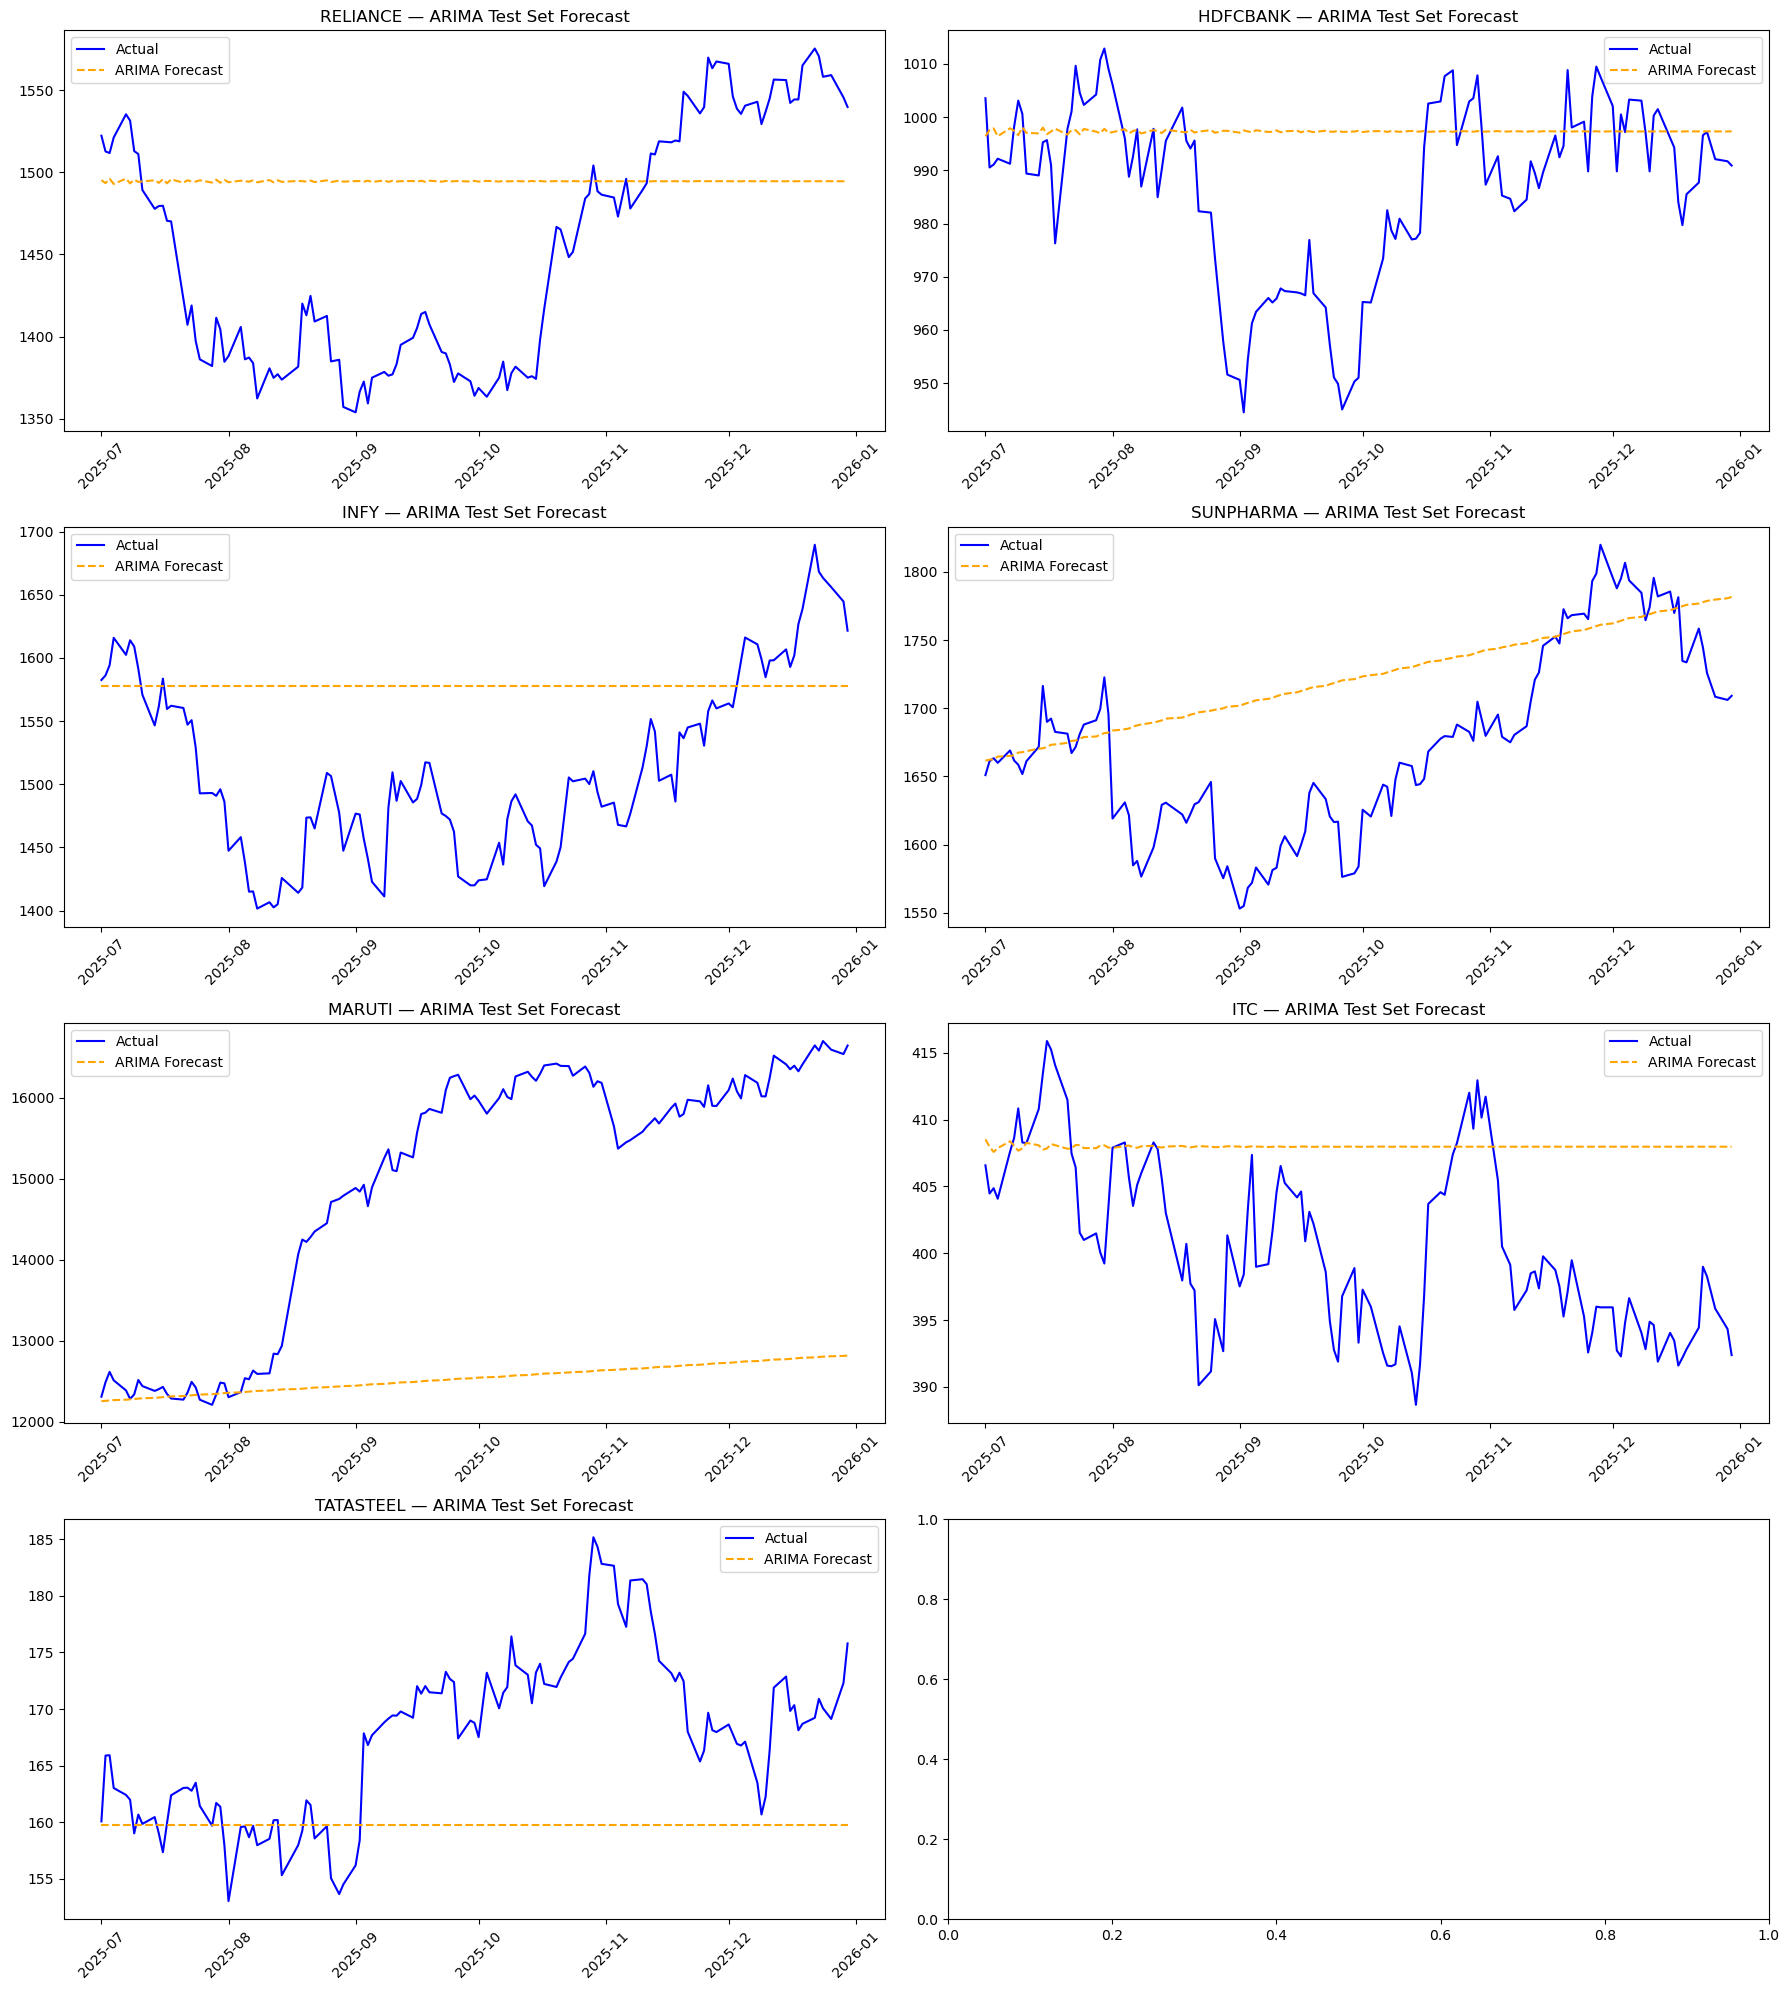

In [6]:
# ── Plot ARIMA results ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for idx, stock in enumerate(close_prices.columns):
    ax = axes[idx]
    test_series  = test_prices[stock]
    test_forecast = arima_forecasts[stock]['test_forecast']
    
    ax.plot(test_series.index, test_series.values, label='Actual', color='blue')
    ax.plot(test_series.index, test_forecast.values, label='ARIMA Forecast', color='orange', linestyle='--')
    ax.set_title(f'{stock} — ARIMA Test Set Forecast')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('task3_arima_results.png', dpi=150)
plt.show()

In [7]:
from prophet import Prophet

def fit_prophet(train_df, stock_name, forecast_steps=5):
    """
    Fits Facebook Prophet model.
    train_df must have columns: ds (datetime), y (price)
    """
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=0.05,   # Controls trend flexibility
        seasonality_prior_scale=10.0
    )
    model.fit(train_df)
    
    future = model.make_future_dataframe(periods=forecast_steps, freq='B')  # Business days
    forecast = model.predict(future)
    
    return model, forecast


prophet_forecasts = {}
prophet_metrics   = {}

for stock in close_prices.columns:
    print(f"\nFitting Prophet for {stock}...")
    
    # Prepare Prophet-format dataframe
    train_series = train_prices[stock].dropna().reset_index()
    train_series.columns = ['ds', 'y']
    train_series['ds'] = pd.to_datetime(train_series['ds']).dt.tz_localize(None)
    
    test_series = test_prices[stock].dropna()
    
    model, forecast = fit_prophet(train_series, stock, forecast_steps=len(test_series) + 2)
    
    # Align forecast with test period
    forecast_indexed = forecast.set_index('ds')
    
    # Get test period forecasts
    test_index_tz_naive = test_series.index.tz_localize(None)
    overlap = forecast_indexed.loc[
        forecast_indexed.index.isin(test_index_tz_naive), 'yhat'
    ]
    
    if len(overlap) > 0:
        min_len = min(len(test_series), len(overlap))
        actual  = test_series.values[:min_len]
        pred    = overlap.values[:min_len]
        
        mape    = np.mean(np.abs((actual - pred) / actual)) * 100
        rmse    = np.sqrt(np.mean((actual - pred) ** 2))
        dir_acc = np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(pred))) * 100
    else:
        mape, rmse, dir_acc = np.nan, np.nan, np.nan
    
    # Next 2 trading day forecasts (last 2 rows of future forecast)
    next2 = forecast.tail(2)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    
    prophet_forecasts[stock] = {
        'model': model,
        'full_forecast': forecast,
        'next_2_days': next2
    }
    prophet_metrics[stock] = {'MAPE': mape, 'RMSE': rmse, 'Dir_Acc': dir_acc}
    print(f"  MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | Dir Acc: {dir_acc:.1f}%")


Fitting Prophet for RELIANCE...


16:15:43 - cmdstanpy - INFO - Chain [1] start processing
16:15:44 - cmdstanpy - INFO - Chain [1] done processing
16:15:45 - cmdstanpy - INFO - Chain [1] start processing


  MAPE: 12.52% | RMSE: 223.72 | Dir Acc: 51.2%

Fitting Prophet for HDFCBANK...


16:15:45 - cmdstanpy - INFO - Chain [1] done processing
16:15:46 - cmdstanpy - INFO - Chain [1] start processing


  MAPE: 3.65% | RMSE: 41.36 | Dir Acc: 55.4%

Fitting Prophet for INFY...


...

  MAPE: 16.80% | RMSE: 3122.92 | Dir Acc: 52.9%

Fitting Prophet for ITC...


16:15:49 - cmdstanpy - INFO - Chain [1] done processing
16:15:49 - cmdstanpy - INFO - Chain [1] start processing


  MAPE: 3.69% | RMSE: 17.52 | Dir Acc: 49.6%

Fitting Prophet for TATASTEEL...


16:15:50 - cmdstanpy - INFO - Chain [1] done processing


  MAPE: 18.71% | RMSE: 34.16 | Dir Acc: 50.4%


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def create_sequences(data, lookback=60):
    """Create sliding window sequences for LSTM input."""
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)


def build_lstm_model(lookback=60):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


lstm_forecasts = {}
lstm_metrics   = {}
LOOKBACK = 60

for stock in close_prices.columns:
    print(f"\nTraining LSTM for {stock}...")
    
    scaler = scalers[stock]
    
    # Prepare full scaled series
    full_scaled = scaler.transform(close_prices[[stock]].dropna()).flatten()
    
    # Split at same point as before
    n_train = len(train_prices[stock].dropna())
    train_s = full_scaled[:n_train]
    test_s  = full_scaled[n_train:]
    
    # Create sequences from training data
    X_train, y_train = create_sequences(train_s, LOOKBACK)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    
    # Build and train
    model = build_lstm_model(LOOKBACK)
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    
    # ── Predict on test set (one step at a time) ───────────────────────────────
    # Use rolling prediction: feed actual past values
    combined = full_scaled  # Full series (train + test)
    predictions_scaled = []
    
    for i in range(n_train, len(combined)):
        x_input = combined[i - LOOKBACK:i].reshape(1, LOOKBACK, 1)
        pred = model.predict(x_input, verbose=0)[0][0]
        predictions_scaled.append(pred)
    
    # Inverse transform
    predictions = scaler.inverse_transform(
        np.array(predictions_scaled).reshape(-1, 1)
    ).flatten()
    
    test_actual = test_prices[stock].dropna().values[:len(predictions)]
    
    mape    = np.mean(np.abs((test_actual - predictions) / test_actual)) * 100
    rmse    = np.sqrt(np.mean((test_actual - predictions) ** 2))
    dir_acc = np.mean(np.sign(np.diff(test_actual)) == np.sign(np.diff(predictions))) * 100
    
    # ── Forecast next 2 days ───────────────────────────────────────────────────
    last_window = full_scaled[-LOOKBACK:]
    next_2 = []
    window = last_window.copy()
    
    for _ in range(2):
        x = window.reshape(1, LOOKBACK, 1)
        p = model.predict(x, verbose=0)[0][0]
        next_2.append(p)
        window = np.append(window[1:], p)
    
    next_2_prices = scaler.inverse_transform(
        np.array(next_2).reshape(-1, 1)
    ).flatten()
    
    lstm_forecasts[stock] = {
        'model': model,
        'test_predictions': predictions,
        'next_2_days': next_2_prices
    }
    lstm_metrics[stock] = {'MAPE': mape, 'RMSE': rmse, 'Dir_Acc': dir_acc}
    print(f"  MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | Dir Acc: {dir_acc:.1f}%")


Training LSTM for RELIANCE...
  MAPE: 1.95% | RMSE: 36.52 | Dir Acc: 44.4%

Training LSTM for HDFCBANK...
  MAPE: 1.04% | RMSE: 12.22 | Dir Acc: 49.2%

Training LSTM for INFY...
  MAPE: 2.19% | RMSE: 39.33 | Dir Acc: 39.5%

Training LSTM for SUNPHARMA...
  MAPE: 1.82% | RMSE: 36.84 | Dir Acc: 50.8%

Training LSTM for MARUTI...
  MAPE: 3.32% | RMSE: 608.94 | Dir Acc: 50.0%

Training LSTM for ITC...
  MAPE: 1.37% | RMSE: 6.40 | Dir Acc: 44.4%

Training LSTM for TATASTEEL...
  MAPE: 2.13% | RMSE: 4.60 | Dir Acc: 45.2%



Volatility & Trend Analysis: RELIANCE
  Recent 30-day Rolling Vol: 0.7646%
  GARCH next-2-day vol forecast: [1.01982949 1.02973916]
  Trend direction (last 30 days): DOWNWARD
  Trend strength: 0.66%


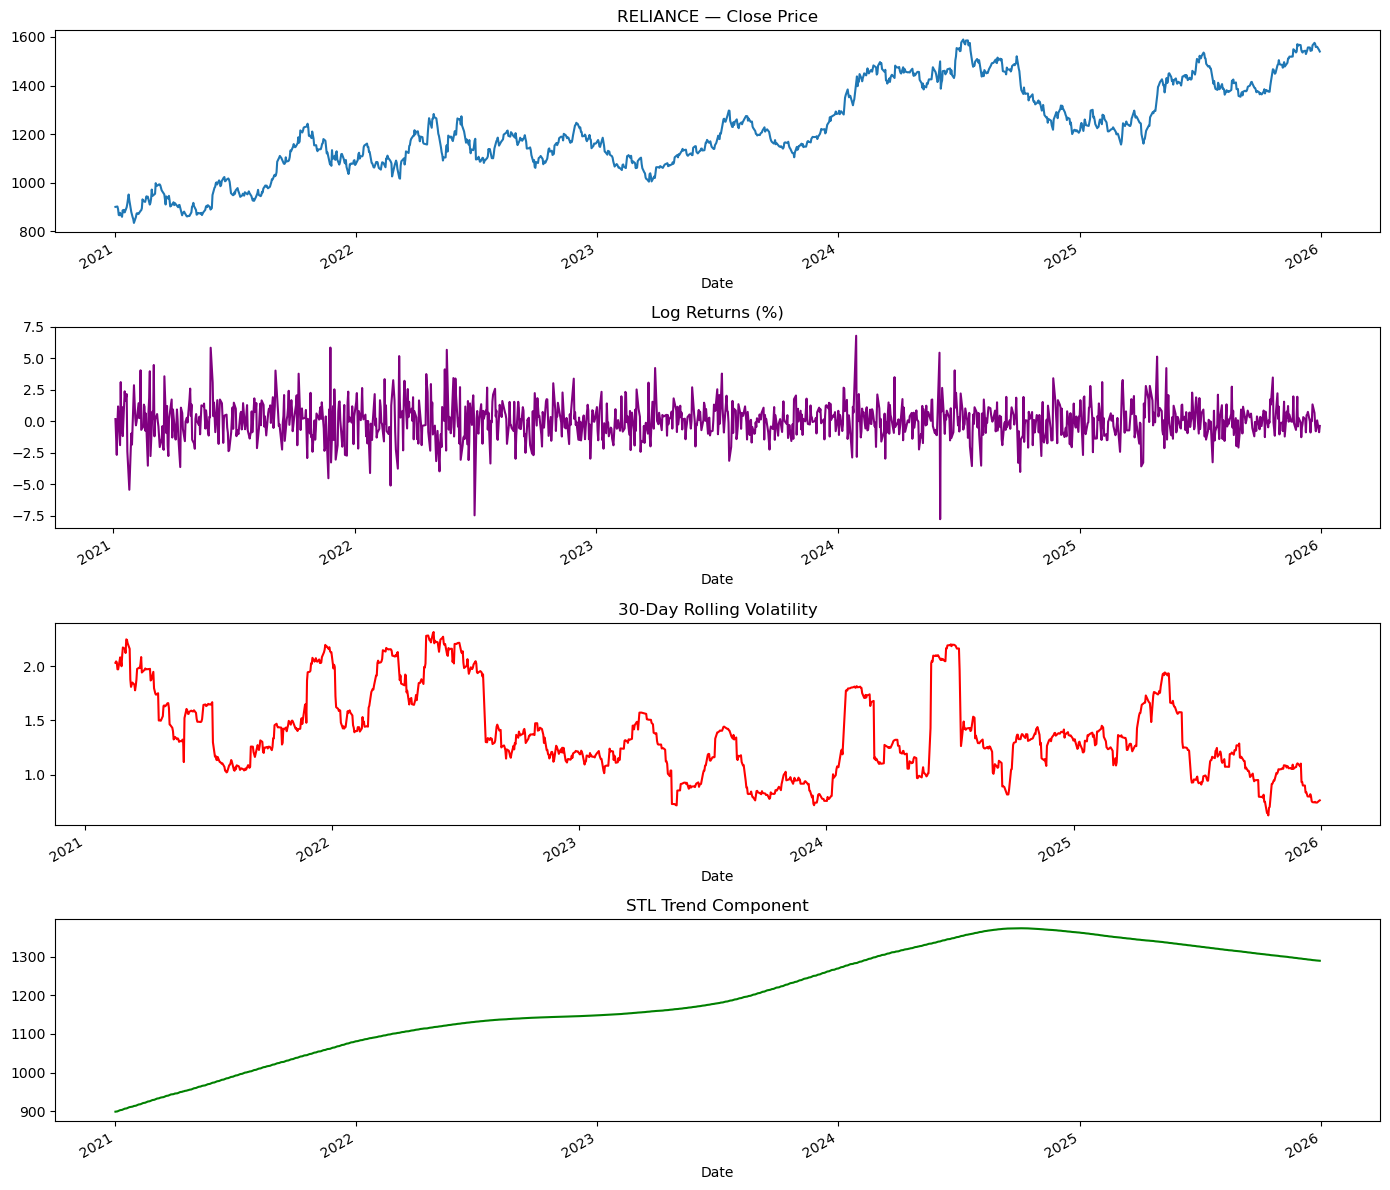


Volatility & Trend Analysis: HDFCBANK
  Recent 30-day Rolling Vol: 0.7239%
  GARCH next-2-day vol forecast: [0.93759061 0.95202543]
  Trend direction (last 30 days): UPWARD
  Trend strength: 1.69%


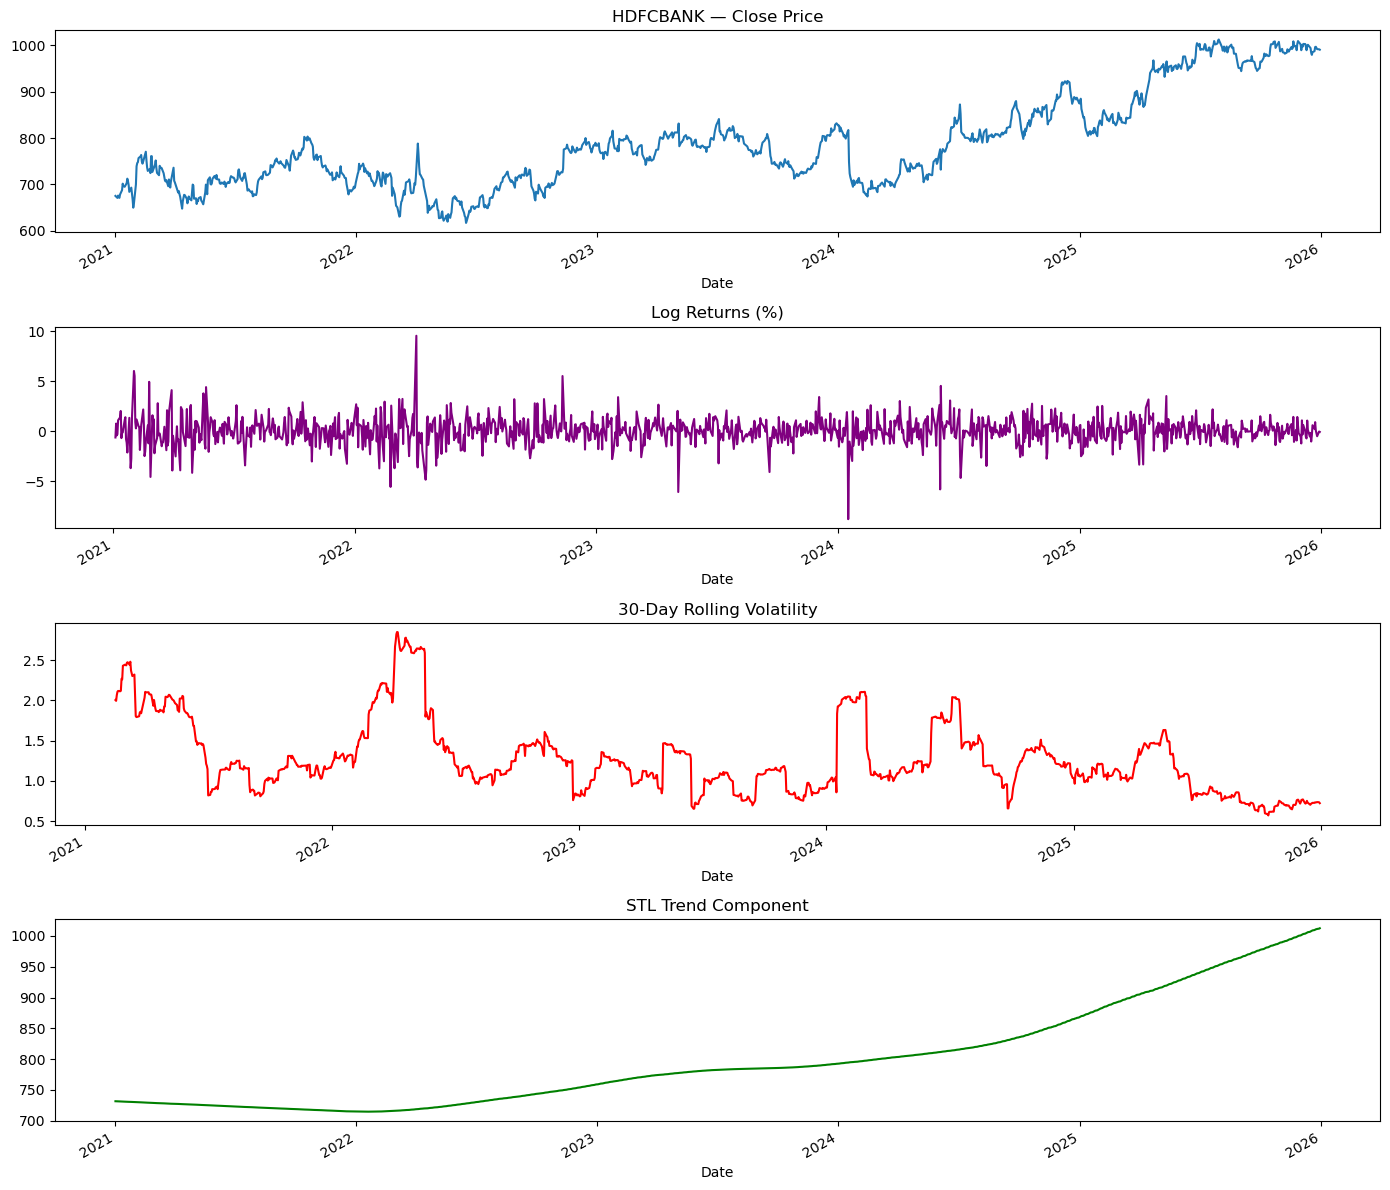


Volatility & Trend Analysis: INFY
  Recent 30-day Rolling Vol: 1.2153%
  GARCH next-2-day vol forecast: [1.51913768 1.52655696]
  Trend direction (last 30 days): UPWARD
  Trend strength: 1.12%


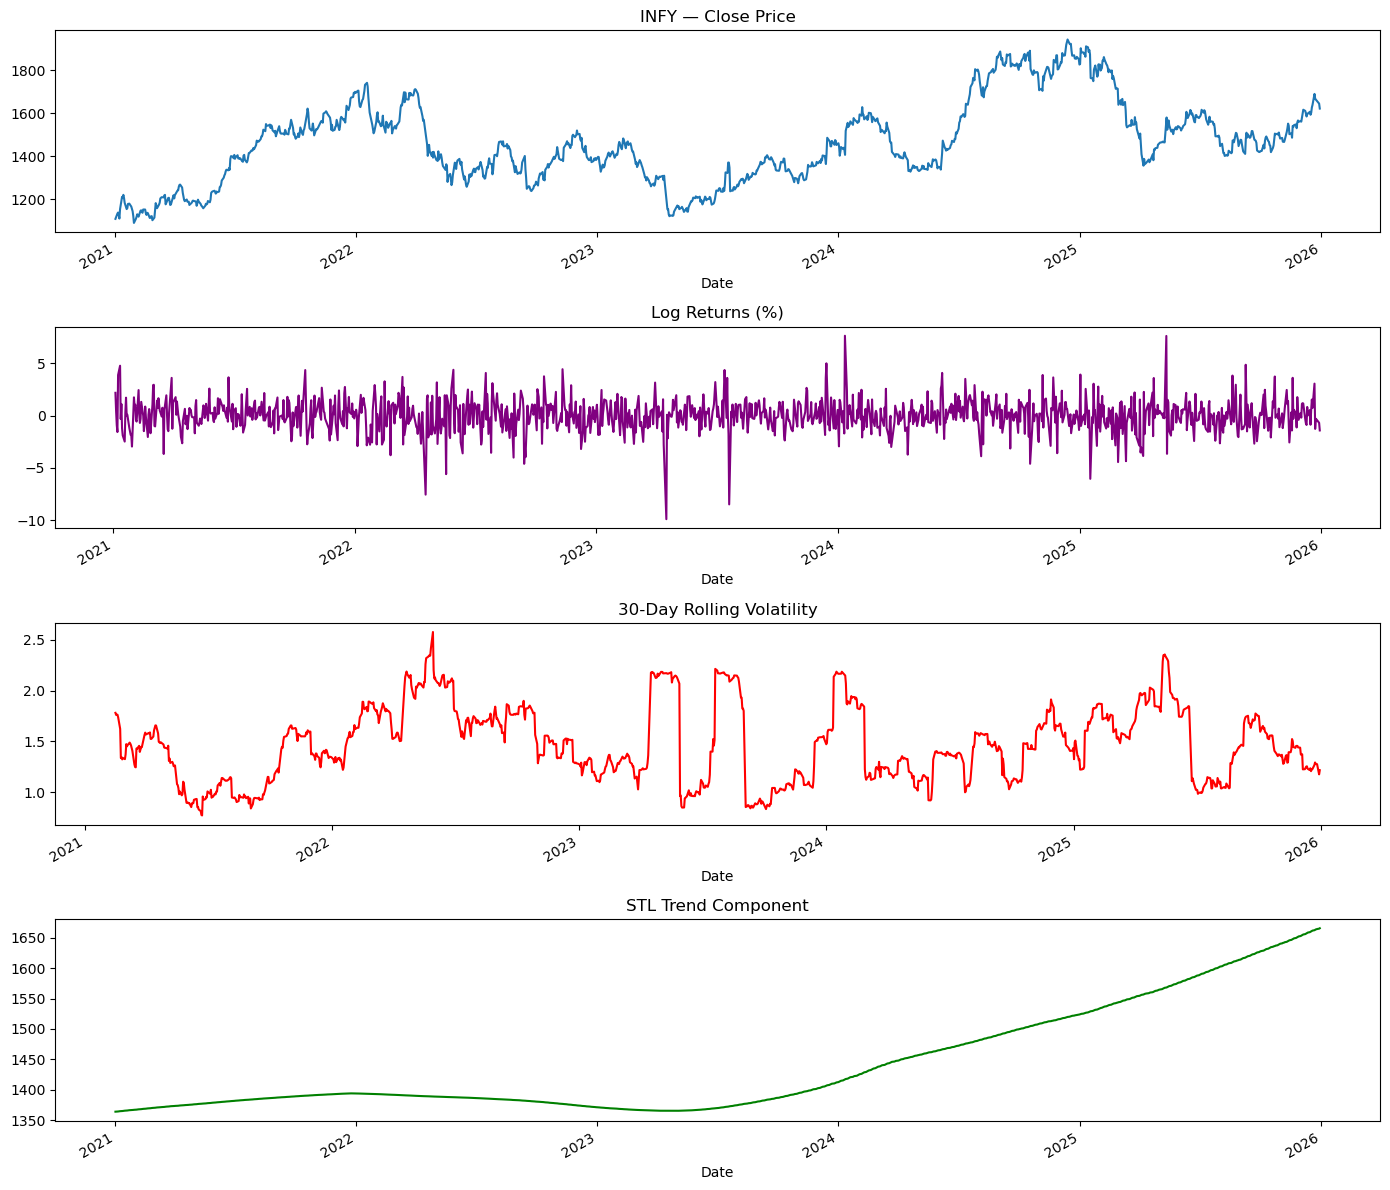


Volatility & Trend Analysis: SUNPHARMA
  Recent 30-day Rolling Vol: 0.9491%
  GARCH next-2-day vol forecast: [1.10189992 1.10227377]
  Trend direction (last 30 days): UPWARD
  Trend strength: 1.62%


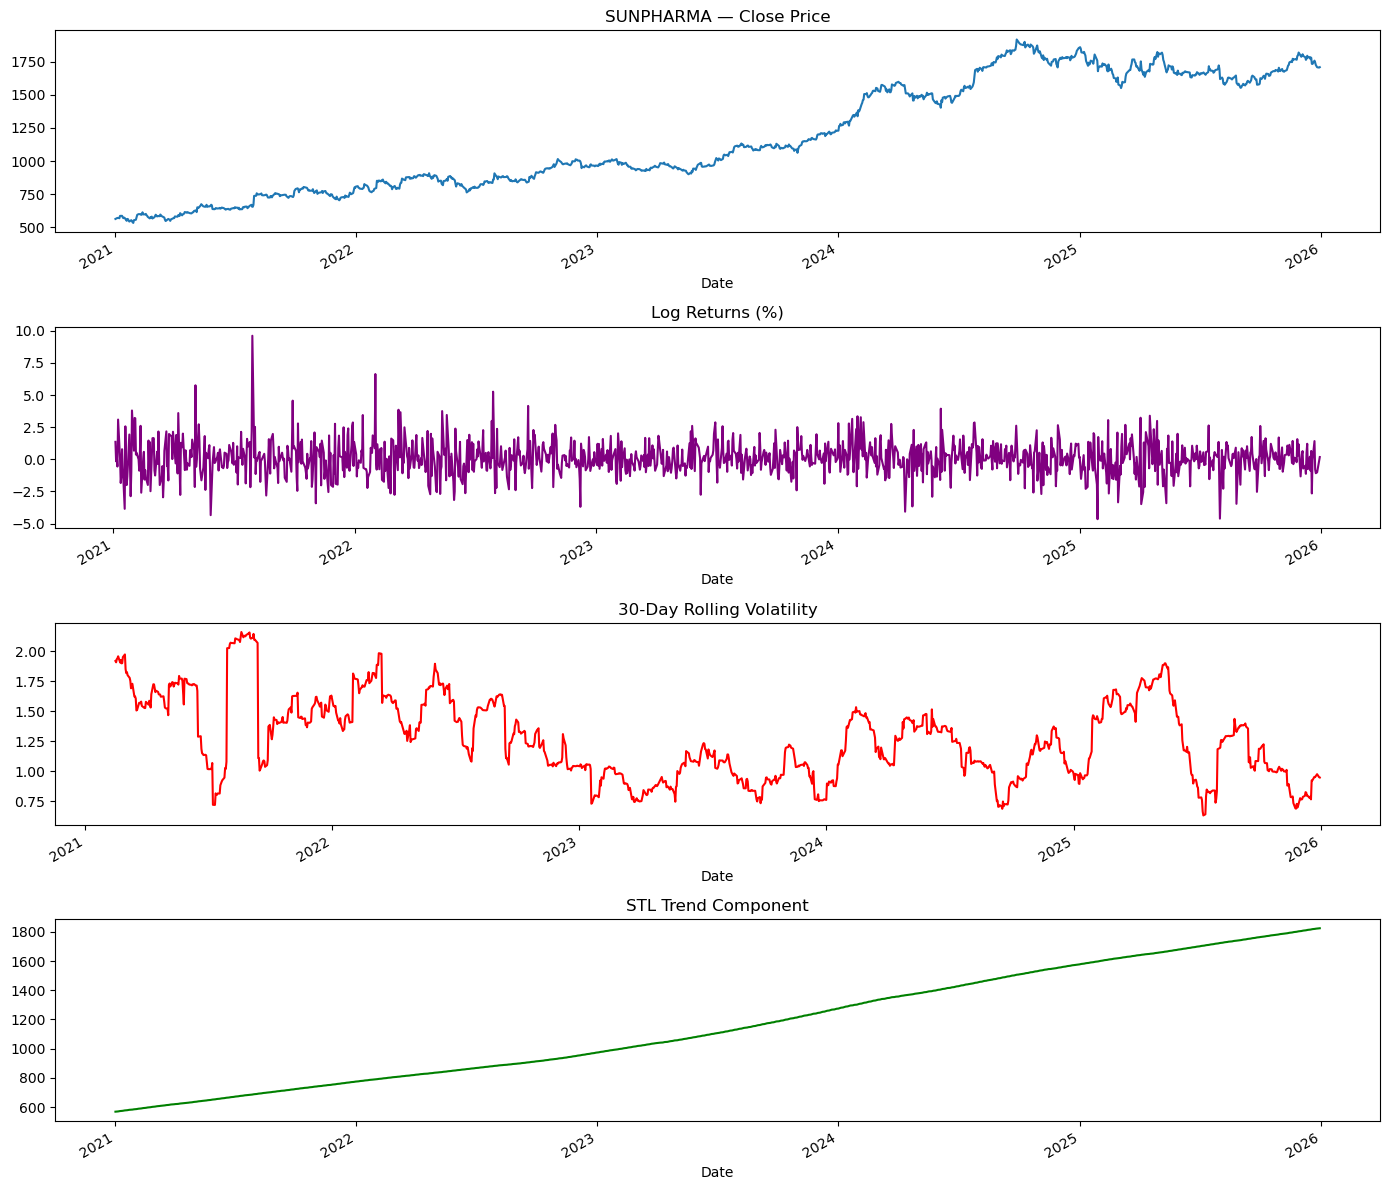


Volatility & Trend Analysis: MARUTI
  Recent 30-day Rolling Vol: 0.9241%
  GARCH next-2-day vol forecast: [1.16766326 1.1698604 ]
  Trend direction (last 30 days): UPWARD
  Trend strength: 2.11%


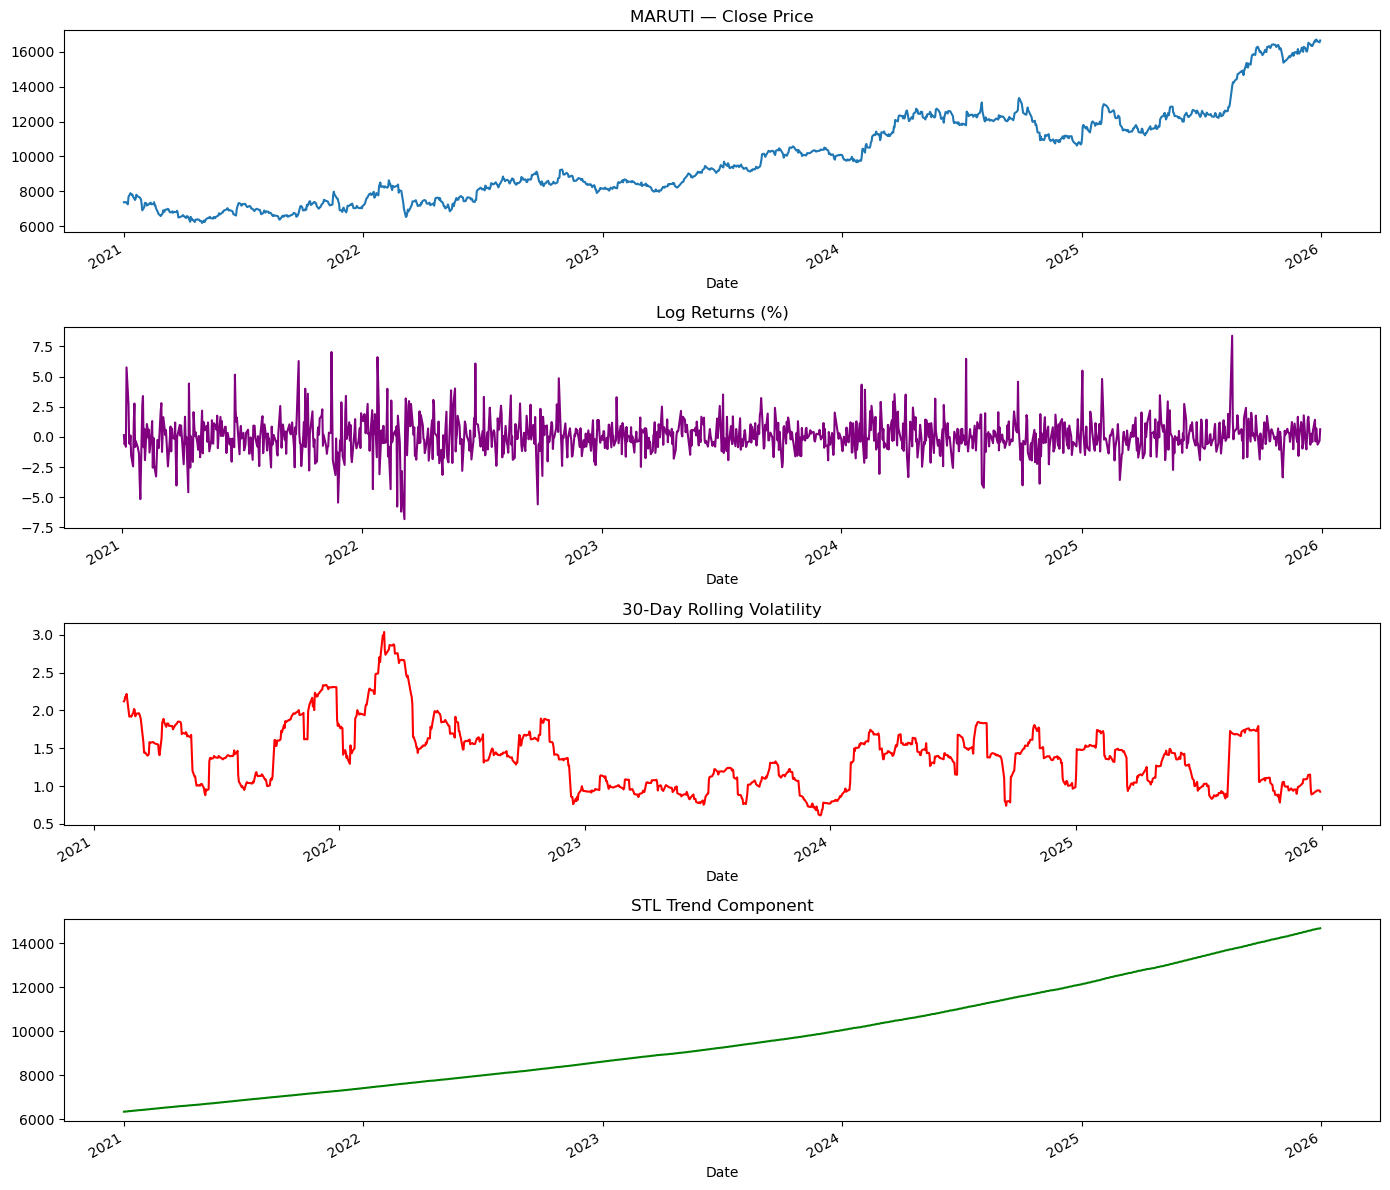


Volatility & Trend Analysis: ITC
  Recent 30-day Rolling Vol: 0.5367%
  GARCH next-2-day vol forecast: [1.00403428 1.04839047]
  Trend direction (last 30 days): DOWNWARD
  Trend strength: 0.23%


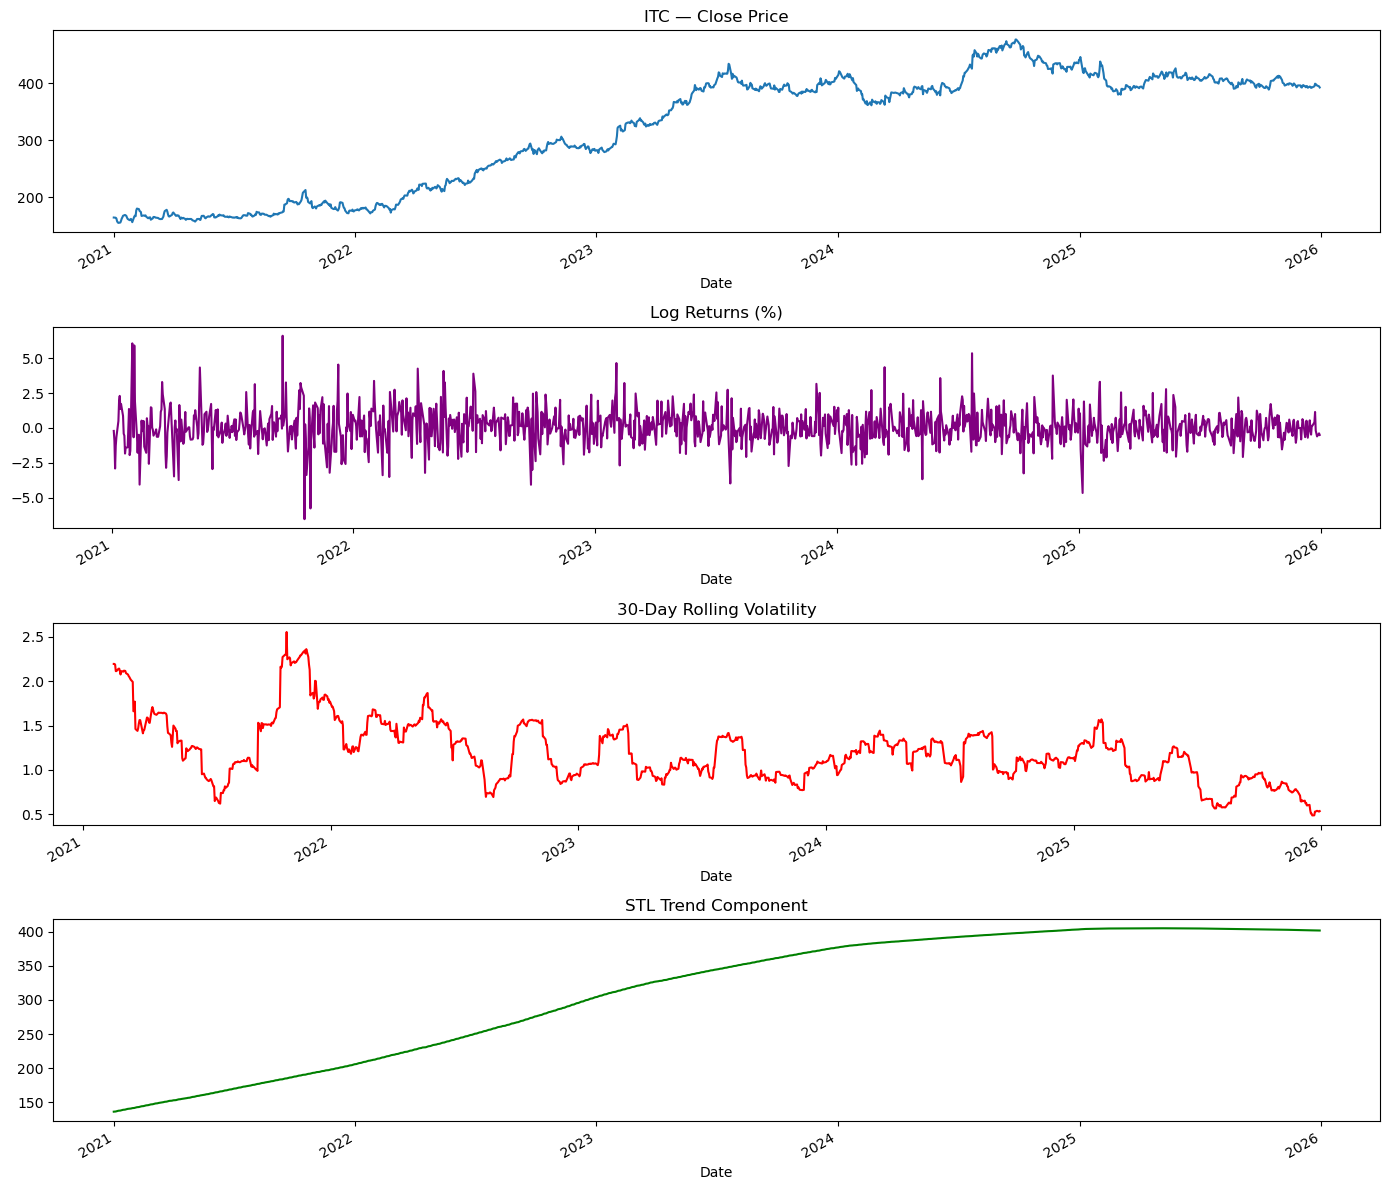


Volatility & Trend Analysis: TATASTEEL
  Recent 30-day Rolling Vol: 1.3898%
  GARCH next-2-day vol forecast: [1.52826774 1.53351744]
  Trend direction (last 30 days): UPWARD
  Trend strength: 1.63%


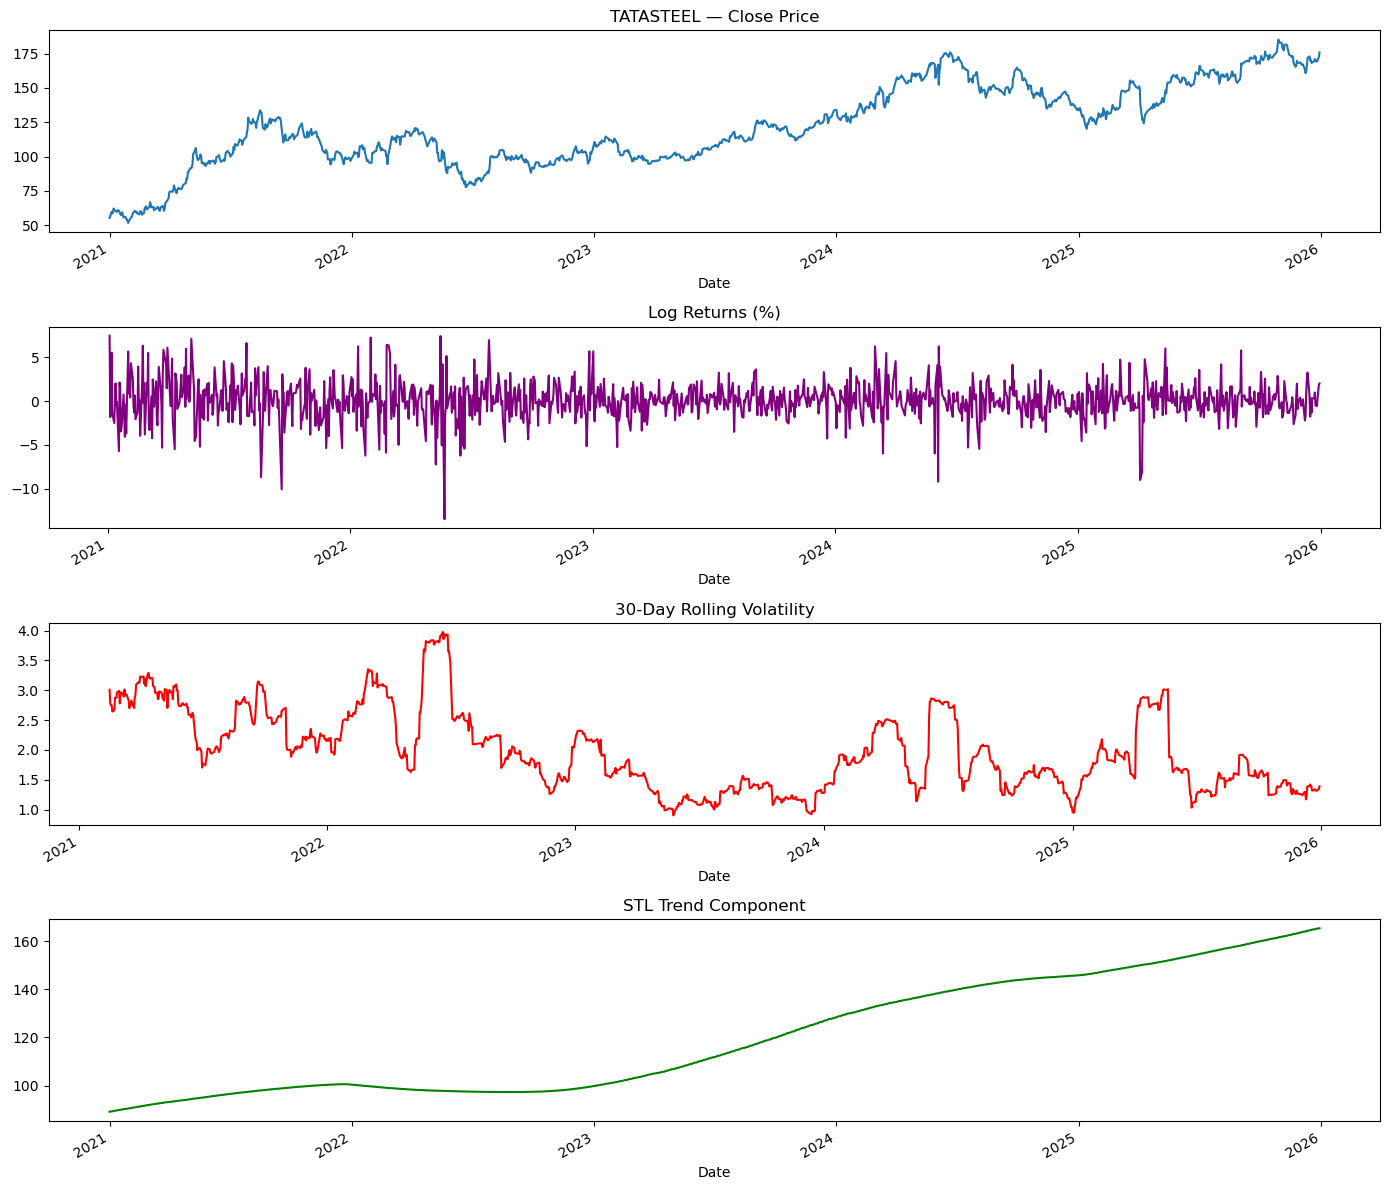

In [9]:
from arch import arch_model
from statsmodels.tsa.seasonal import STL

volatility_results = {}

for stock in close_prices.columns:
    print(f"\n{'='*50}")
    print(f"Volatility & Trend Analysis: {stock}")
    
    series = close_prices[stock].dropna()
    
    # ── 1. Log Returns ─────────────────────────────────────────────────────────
    log_ret = np.log(series / series.shift(1)).dropna() * 100  # In percentage
    
    # ── 2. Rolling Standard Deviation (30-day) ─────────────────────────────────
    rolling_vol = log_ret.rolling(window=30).std()
    recent_vol  = rolling_vol.iloc[-1]
    print(f"  Recent 30-day Rolling Vol: {recent_vol:.4f}%")
    
    # ── 3. GARCH(1,1) ──────────────────────────────────────────────────────────
    try:
        garch = arch_model(log_ret, vol='Garch', p=1, q=1, dist='normal')
        garch_fit = garch.fit(disp='off')
        garch_forecast = garch_fit.forecast(horizon=2)
        garch_vol_next2 = np.sqrt(garch_forecast.variance.values[-1])  # Std dev forecast
        print(f"  GARCH next-2-day vol forecast: {garch_vol_next2}")
    except Exception as e:
        print(f"  GARCH failed: {e}")
        garch_vol_next2 = np.array([recent_vol, recent_vol])
    
    # ── 4. STL Decomposition ───────────────────────────────────────────────────
    stl = STL(series, period=252, robust=True)
    stl_result = stl.fit()
    
    trend_series = stl_result.trend
    trend_direction = 'UPWARD' if trend_series.iloc[-1] > trend_series.iloc[-30] else 'DOWNWARD'
    trend_strength = abs(trend_series.iloc[-1] - trend_series.iloc[-30]) / trend_series.iloc[-30] * 100
    
    print(f"  Trend direction (last 30 days): {trend_direction}")
    print(f"  Trend strength: {trend_strength:.2f}%")
    
    # Store results
    volatility_results[stock] = {
        'log_returns': log_ret,
        'rolling_vol_30d': rolling_vol,
        'recent_vol': recent_vol,
        'garch_next2_vol': garch_vol_next2,
        'trend_direction': trend_direction,
        'trend_strength': trend_strength,
        'stl': stl_result
    }
    
    # ── Plot ───────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    
    series.plot(ax=axes[0], title=f'{stock} — Close Price')
    log_ret.plot(ax=axes[1], title='Log Returns (%)', color='purple')
    rolling_vol.plot(ax=axes[2], title='30-Day Rolling Volatility', color='red')
    stl_result.trend.plot(ax=axes[3], title='STL Trend Component', color='green')
    
    plt.tight_layout()
    plt.savefig(f'task4_volatility_{stock}.png', dpi=100)
    plt.show()

In [10]:
TOTAL_CAPITAL = 1_000_000  # ₹10,00,000

# ── Strategy A: Forecast-Guided (predicted 2-day return) ──────────────────────
# Use ensemble of ARIMA + Prophet + LSTM average as the forecast

predicted_returns = {}
last_known_price  = {}

for stock in close_prices.columns:
    last_price = close_prices[stock].dropna().iloc[-1]
    last_known_price[stock] = last_price
    
    # Get day-2 forecasts from each model
    arima_d2   = arima_forecasts[stock]['next_2_days'].iloc[-1]
    prophet_d2 = prophet_forecasts[stock]['next_2_days']['yhat'].iloc[-1]
    lstm_d2    = lstm_forecasts[stock]['next_2_days'][-1]
    
    # Ensemble: simple average
    ensemble_d2 = np.mean([arima_d2, prophet_d2, lstm_d2])
    pred_return = (ensemble_d2 - last_price) / last_price * 100
    predicted_returns[stock] = pred_return
    
    print(f"{stock:12s} | Last: ₹{last_price:8.2f} | "
          f"ARIMA: ₹{arima_d2:8.2f} | Prophet: ₹{prophet_d2:8.2f} | "
          f"LSTM: ₹{lstm_d2:8.2f} | Ensemble D2: ₹{ensemble_d2:8.2f} | "
          f"Predicted Return: {pred_return:+.2f}%")

RELIANCE     | Last: ₹ 1539.80 | ARIMA: ₹ 1493.44 | Prophet: ₹ 1147.69 | LSTM: ₹ 1542.53 | Ensemble D2: ₹ 1394.55 | Predicted Return: -9.43%
HDFCBANK     | Last: ₹  990.90 | ARIMA: ₹  997.54 | Prophet: ₹ 1067.58 | LSTM: ₹  984.58 | Ensemble D2: ₹ 1016.57 | Predicted Return: +2.59%
INFY         | Last: ₹ 1621.60 | ARIMA: ₹ 1577.65 | Prophet: ₹ 1691.62 | LSTM: ₹ 1629.53 | Ensemble D2: ₹ 1632.93 | Predicted Return: +0.70%
SUNPHARMA    | Last: ₹ 1709.10 | ARIMA: ₹ 1662.31 | Prophet: ₹ 1850.67 | LSTM: ₹ 1726.62 | Ensemble D2: ₹ 1746.53 | Predicted Return: +2.19%
MARUTI       | Last: ₹16647.00 | ARIMA: ₹12257.40 | Prophet: ₹11562.95 | LSTM: ₹15911.31 | Ensemble D2: ₹13243.88 | Predicted Return: -20.44%
ITC          | Last: ₹  392.38 | ARIMA: ₹  407.97 | Prophet: ₹  397.61 | LSTM: ₹  397.45 | Ensemble D2: ₹  401.01 | Predicted Return: +2.20%
TATASTEEL    | Last: ₹  175.80 | ARIMA: ₹  159.76 | Prophet: ₹  125.76 | LSTM: ₹  169.86 | Ensemble D2: ₹  151.79 | Predicted Return: -13.66%


In [11]:
# ── Strategy B: Volatility-Aware Sizing ───────────────────────────────────────
# Weight inversely proportional to recent volatility

vol_dict = {stock: volatility_results[stock]['recent_vol'] for stock in close_prices.columns}
inv_vol  = {stock: 1.0 / v for stock, v in vol_dict.items()}
inv_vol_sum = sum(inv_vol.values())
vol_weights = {stock: inv_vol[stock] / inv_vol_sum for stock in close_prices.columns}

# ── Combine Strategy A + B ─────────────────────────────────────────────────────
# Only invest in stocks with POSITIVE predicted returns
# Combine: 60% weight from A (return ranking), 40% from B (vol sizing)

# Strategy A weights: proportional to positive predicted return
pos_returns = {s: max(r, 0) for s, r in predicted_returns.items()}
pos_sum = sum(pos_returns.values())

if pos_sum == 0:
    # If all negative, use smallest magnitude losses
    pos_returns = {s: 1.0 for s in close_prices.columns}
    pos_sum = sum(pos_returns.values())

ret_weights = {s: pos_returns[s] / pos_sum for s in close_prices.columns}

# Final combined weight
alpha = 0.6  # Weight on forecast-guided
beta  = 0.4  # Weight on volatility-aware

final_weights = {}
for stock in close_prices.columns:
    final_weights[stock] = alpha * ret_weights[stock] + beta * vol_weights[stock]

# Normalize to sum = 1
weight_sum = sum(final_weights.values())
final_weights = {s: w / weight_sum for s, w in final_weights.items()}

In [12]:
# ── Build Allocation Table ─────────────────────────────────────────────────────
allocation_table = []

for stock in close_prices.columns:
    w       = final_weights[stock]
    amount  = w * TOTAL_CAPITAL
    price   = last_known_price[stock]
    shares  = int(amount // price)   # Whole shares only
    actual_amount = shares * price
    
    allocation_table.append({
        'Stock': stock,
        'Sector': {
            'RELIANCE': 'Energy', 'HDFCBANK': 'Banking', 'INFY': 'IT',
            'SUNPHARMA': 'Pharma', 'MARUTI': 'Auto',
            'ITC': 'FMCG', 'TATASTEEL': 'Metals'
        }[stock],
        'Last Price (₹)': round(price, 2),
        'Predicted 2-Day Return (%)': round(predicted_returns[stock], 2),
        'Recent Volatility (%)': round(vol_dict[stock], 4),
        'Weight (%)': round(w * 100, 2),
        'Allocated Amount (₹)': round(actual_amount, 2),
        'Shares to Buy': shares
    })

alloc_df = pd.DataFrame(allocation_table)
total_deployed = alloc_df['Allocated Amount (₹)'].sum()
alloc_df.loc[len(alloc_df)] = ['TOTAL', '', '', '', '', 100.0, round(total_deployed, 2), '']

print(alloc_df.to_string(index=False))
alloc_df.to_csv('../outputs/day2_portfolio_allocation.csv', index=False)

    Stock  Sector Last Price (₹) Predicted 2-Day Return (%) Recent Volatility (%)  Weight (%)  Allocated Amount (₹) Shares to Buy
 RELIANCE  Energy         1539.8                      -9.43                0.7646        6.36              63131.80            41
 HDFCBANK Banking          990.9                       2.59                0.7239       26.95             269524.81           272
     INFY      IT         1621.6                        0.7                1.2153        9.46              94052.80            58
SUNPHARMA  Pharma         1709.1                       2.19                0.9491       22.23             222182.74           130
   MARUTI    Auto        16647.0                     -20.44                0.9241        5.26              49941.00             3
      ITC    FMCG         392.38                        2.2                0.5367       26.24             262107.64           668
TATASTEEL  Metals          175.8                     -13.66                1.3898        3

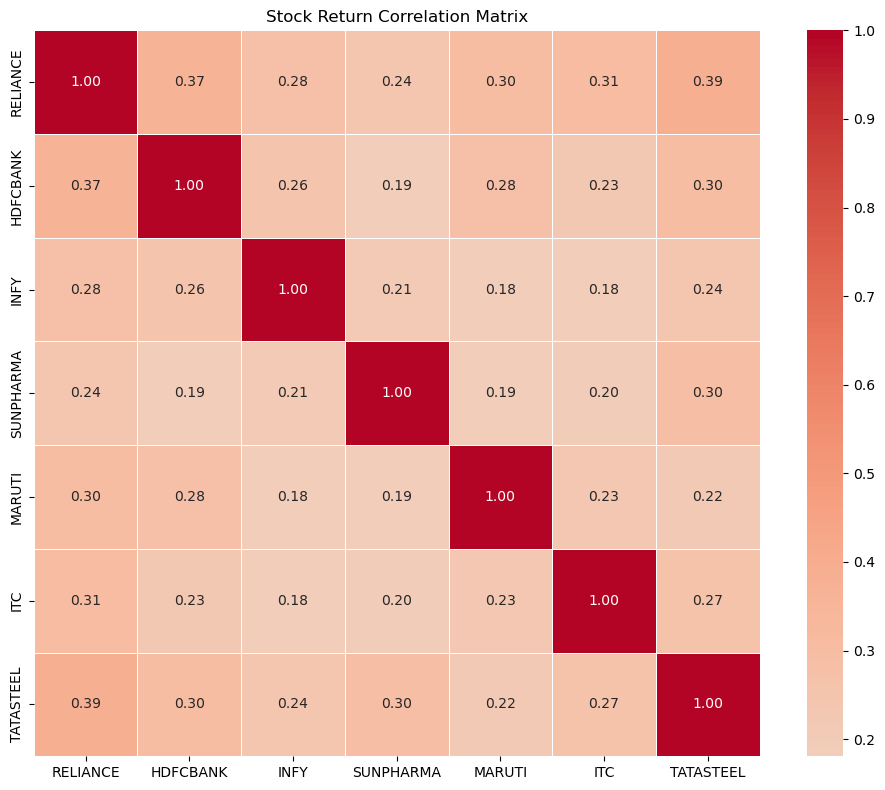


Low correlation pairs (|r| < 0.3):
  RELIANCE — INFY: 0.28
  RELIANCE — SUNPHARMA: 0.24
  RELIANCE — MARUTI: 0.30
  HDFCBANK — INFY: 0.26
  HDFCBANK — SUNPHARMA: 0.19
  HDFCBANK — MARUTI: 0.28
  HDFCBANK — ITC: 0.23
  HDFCBANK — TATASTEEL: 0.30
  INFY — SUNPHARMA: 0.21
  INFY — MARUTI: 0.18
  INFY — ITC: 0.18
  INFY — TATASTEEL: 0.24
  SUNPHARMA — MARUTI: 0.19
  SUNPHARMA — ITC: 0.20
  SUNPHARMA — TATASTEEL: 0.30
  MARUTI — ITC: 0.23
  MARUTI — TATASTEEL: 0.22
  ITC — TATASTEEL: 0.27


In [13]:
# ── Correlation Matrix (for Strategy C bonus) ─────────────────────────────────
import seaborn as sns

corr_matrix = log_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Stock Return Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/day2_task5_correlation_heatmap.png', dpi=150)
plt.show()

# Low-correlation pairs are good for diversification
print("\nLow correlation pairs (|r| < 0.3):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) < 0.3:
            print(f"  {corr_matrix.columns[i]} — {corr_matrix.columns[j]}: {val:.2f}")

In [14]:
# ── Build comprehensive comparison table ───────────────────────────────────────
comparison_rows = []

for stock in close_prices.columns:
    a_m = arima_metrics[stock]
    p_m = prophet_metrics[stock]
    l_m = lstm_metrics[stock]
    
    comparison_rows.append({
        'Stock': stock,
        'ARIMA_MAPE':     round(a_m['MAPE'], 2),
        'ARIMA_RMSE':     round(a_m['RMSE'], 2),
        'ARIMA_DirAcc':   round(a_m['Dir_Acc'], 1),
        'Prophet_MAPE':   round(p_m['MAPE'], 2) if not np.isnan(p_m['MAPE']) else 'N/A',
        'Prophet_RMSE':   round(p_m['RMSE'], 2) if not np.isnan(p_m['RMSE']) else 'N/A',
        'Prophet_DirAcc': round(p_m['Dir_Acc'], 1) if not np.isnan(p_m['Dir_Acc']) else 'N/A',
        'LSTM_MAPE':      round(l_m['MAPE'], 2),
        'LSTM_RMSE':      round(l_m['RMSE'], 2),
        'LSTM_DirAcc':    round(l_m['Dir_Acc'], 1),
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv('../outputs/day2_task6_model_comparison.csv', index=False)

    Stock  ARIMA_MAPE  ARIMA_RMSE  ARIMA_DirAcc  Prophet_MAPE  Prophet_RMSE  Prophet_DirAcc  LSTM_MAPE  LSTM_RMSE  LSTM_DirAcc
 RELIANCE        5.01       82.11          54.8         12.52        223.72            51.2       1.95      36.52         44.4
 HDFCBANK        1.44       19.50          47.6          3.65         41.36            55.4       1.04      12.22         49.2
     INFY        5.41       93.74           0.8          9.57        155.93            59.5       2.19      39.33         39.5
SUNPHARMA        3.51       71.02          58.1          9.96        184.46            61.2       1.82      36.84         50.8
   MARUTI       15.14     2786.81          55.6         16.80       3122.92            52.9       3.32     608.94         50.0
      ITC        2.16       10.06          50.8          3.69         17.52            49.6       1.37       6.40         44.4
TATASTEEL        4.99       10.64           0.0         18.71         34.16            50.4       2.13       4.

## Day-2

In [15]:
# Mapping from short name to .NS symbol
name_to_symbol = {
    'RELIANCE':  'RELIANCE.NS',
    'HDFCBANK':  'HDFCBANK.NS',
    'INFY':      'INFY.NS',
    'SUNPHARMA': 'SUNPHARMA.NS',
    'MARUTI':    'MARUTI.NS',
    'ITC':       'ITC.NS',
    'TATASTEEL': 'TATASTEEL.NS'
}

# Reverse mapping: .NS symbol → short name
symbol_to_name = {v: k for k, v in name_to_symbol.items()}

# Short names list (matches arima_forecasts keys)
stock_names = list(arima_forecasts.keys())

print("Stock names:", stock_names)

Stock names: ['RELIANCE', 'HDFCBANK', 'INFY', 'SUNPHARMA', 'MARUTI', 'ITC', 'TATASTEEL']


In [16]:
# ============================================================
# DAY 2: FETCH LATEST PRICES
# ============================================================

latest_prices = {}

print("Fetching latest available prices...\n")

for name in stock_names:
    symbol = name_to_symbol[name]
    try:
        df = yf.download(symbol, period='5d', interval='1d', auto_adjust=True)
        
        if df.empty:
            print(f"{name:<12} ⚠️  No data found — skipping")
            continue
        
        latest_price        = float(df['Close'].iloc[-1])
        latest_date         = df.index[-1].date()
        latest_prices[name] = latest_price
        print(f"{name:<12} ({symbol:<15}) Latest Close: ₹{latest_price:>10.2f}  (as of {latest_date})")
    
    except Exception as e:
        print(f"{name:<12} ❌ Error: {e} — skipping")

print(f"\nTotal stocks fetched: {len(latest_prices)}")
print("Note: Use these as your reference prices for today's trades.")

Fetching latest available prices...



[*********************100%***********************]  1 of 1 completed


RELIANCE     (RELIANCE.NS    ) Latest Close: ₹   1364.00  (as of 2026-05-12)


[*********************100%***********************]  1 of 1 completed


HDFCBANK     (HDFCBANK.NS    ) Latest Close: ₹    750.45  (as of 2026-05-12)


...

MARUTI       (MARUTI.NS      ) Latest Close: ₹  13172.00  (as of 2026-05-12)


[*********************100%***********************]  1 of 1 completed


ITC          (ITC.NS         ) Latest Close: ₹    300.70  (as of 2026-05-12)


[*********************100%***********************]  1 of 1 completed

TATASTEEL    (TATASTEEL.NS   ) Latest Close: ₹    212.00  (as of 2026-05-12)

Total stocks fetched: 7
Note: Use these as your reference prices for today's trades.


In [17]:
# Check prophet_forecasts structure
print(type(prophet_forecasts))
print("\nKeys:", list(prophet_forecasts.keys()))
print("\nFirst entry sample:")
first_key = list(prophet_forecasts.keys())[0]
print(f"Key: {first_key}")
print(type(prophet_forecasts[first_key]))
print(prophet_forecasts[first_key])

<class 'dict'>

Keys: ['RELIANCE', 'HDFCBANK', 'INFY', 'SUNPHARMA', 'MARUTI', 'ITC', 'TATASTEEL']

First entry sample:
Key: RELIANCE
<class 'dict'>
{'model': <prophet.forecaster.Prophet object at 0x000001DD671C5D30>, 'full_forecast':              ds        trend   yhat_lower   yhat_upper  trend_lower  \
0    2021-01-01   956.610261   833.292156   958.422958   956.610261   
1    2021-01-04   955.277202   837.638159   966.702582   955.277202   
2    2021-01-05   954.832850   836.808292   965.808738   954.832850   
3    2021-01-06   954.388497   845.729173   969.270500   954.388497   
4    2021-01-07   953.944144   845.857040   975.182381   953.944144   
...         ...          ...          ...          ...          ...   
1232 2025-12-18  1217.356609  1028.720911  1275.473533  1100.132472   
1233 2025-12-19  1216.994388  1023.760639  1270.543365  1098.813190   
1234 2025-12-22  1215.907727  1014.454809  1270.945267  1096.128206   
1235 2025-12-23  1215.545507  1013.241914  1272.992819  

In [18]:
# ============================================================
# DAY 2: MODEL FORECASTS FOR TODAY AND TOMORROW
# ============================================================

print("=" * 78)
print(f"{'Stock':<12} {'Last Close':>12} {'Day1 Forecast':>15} {'Day2 Forecast':>15} {'Signal'}")
print("=" * 78)

signals = {}

for name in stock_names:
    
    if name not in latest_prices:
        print(f"{name:<12} ⚠️  Skipping — no latest price")
        continue
    
    if name not in arima_forecasts:
        print(f"{name:<12} ⚠️  Skipping — no ARIMA forecast")
        continue

    if name not in prophet_forecasts:
        print(f"{name:<12} ⚠️  Skipping — no Prophet forecast")
        continue
    
    last_price = latest_prices[name]
    
    # ARIMA forecast
    arima_day1 = float(arima_forecasts[name]['next_2_days'].iloc[0])
    arima_day2 = float(arima_forecasts[name]['next_2_days'].iloc[1])
    
    # Prophet forecast
    prophet_day1 = float(prophet_forecasts[name]['next_2_days']['yhat'].iloc[0])
    prophet_day2 = float(prophet_forecasts[name]['next_2_days']['yhat'].iloc[1])
    
    # Ensemble average of both models
    ens_day1 = (arima_day1 + prophet_day1) / 2
    ens_day2 = (arima_day2 + prophet_day2) / 2
    
    # Signal based on predicted return
    predicted_return = (ens_day2 - last_price) / last_price * 100
    
    if predicted_return > 1:
        signal = "STRONG BUY ✅"
    elif predicted_return > 0:
        signal = "BUY ✅"
    elif predicted_return > -1:
        signal = "NEUTRAL ⚠️"
    else:
        signal = "SKIP ❌"
    
    signals[name] = {
        'symbol':           name_to_symbol[name],
        'signal':           signal,
        'last_price':       last_price,
        'arima_day1':       round(arima_day1, 2),
        'arima_day2':       round(arima_day2, 2),
        'prophet_day1':     round(prophet_day1, 2),
        'prophet_day2':     round(prophet_day2, 2),
        'ens_day1':         round(ens_day1, 2),
        'ens_day2':         round(ens_day2, 2),
        'predicted_return': round(predicted_return, 2)
    }
    
    print(f"{name:<12} ₹{last_price:>10.2f}  ₹{ens_day1:>12.2f}  ₹{ens_day2:>12.2f}  {signal}")

print("=" * 78)

# Detailed breakdown
print("\nDetailed Model Breakdown:")
print(f"{'Stock':<12} {'ARIMA D1':>10} {'ARIMA D2':>10} {'Prophet D1':>12} {'Prophet D2':>12} {'Pred Ret%':>10}")
print("-" * 70)
for name, info in signals.items():
    print(f"{name:<12} ₹{info['arima_day1']:>8.2f}  ₹{info['arima_day2']:>8.2f}  "
          f"₹{info['prophet_day1']:>10.2f}  ₹{info['prophet_day2']:>10.2f}  "
          f"{info['predicted_return']:>+8.2f}%")

Stock          Last Close   Day1 Forecast   Day2 Forecast Signal
RELIANCE     ₹   1364.00  ₹     1320.64  ₹     1320.56  SKIP ❌
HDFCBANK     ₹    750.45  ₹     1032.08  ₹     1032.56  STRONG BUY ✅
INFY         ₹   1140.30  ₹     1633.71  ₹     1634.63  STRONG BUY ✅
SUNPHARMA    ₹   1845.70  ₹     1754.07  ₹     1756.49  SKIP ❌
MARUTI       ₹  13172.00  ₹    11901.75  ₹    11910.17  SKIP ❌
ITC          ₹    300.70  ₹      402.94  ₹      402.79  STRONG BUY ✅
TATASTEEL    ₹    212.00  ₹      142.72  ₹      142.76  SKIP ❌

Detailed Model Breakdown:
Stock          ARIMA D1   ARIMA D2   Prophet D1   Prophet D2  Pred Ret%
----------------------------------------------------------------------
RELIANCE     ₹ 1495.23  ₹ 1493.44  ₹   1146.05  ₹   1147.69     -3.18%
HDFCBANK     ₹  996.41  ₹  997.54  ₹   1067.76  ₹   1067.58    +37.59%
INFY         ₹ 1577.65  ₹ 1577.65  ₹   1689.78  ₹   1691.62    +43.35%
SUNPHARMA    ₹ 1661.62  ₹ 1662.31  ₹   1846.53  ₹   1850.67     -4.83%
MARUTI       ₹12252.85

In [19]:
# ============================================================
# DAY 2: FINAL BUYING PLAN
# ============================================================

TOTAL_CAPITAL = 1_000_000  # ₹10,00,000

buying_plan = []

# --- Strategy B: Inverse Volatility Weights ---
vol_weights = {}
for name in stock_names:
    if name not in signals:
        continue
    symbol = name_to_symbol[name]
    try:
        recent_df    = yf.download(symbol, period='60d', interval='1d', auto_adjust=True)
        recent_close = recent_df['Close'].squeeze()
        log_ret      = np.log(recent_close / recent_close.shift(1)).dropna()
        recent_vol   = float(log_ret.std())
        vol_weights[name] = 1 / recent_vol if recent_vol > 0 else 0
    except:
        vol_weights[name] = 0

total_vol_w = sum(vol_weights.values())
vol_weights = {n: w / total_vol_w for n, w in vol_weights.items()}

# --- Strategy A: Forecast Return Weights ---
ret_weights = {}
for name in signals.keys():
    pred_ret = max(signals[name]['predicted_return'], 0)
    ret_weights[name] = pred_ret

total_ret_w = sum(ret_weights.values())
if total_ret_w == 0:
    ret_weights = {n: 1/len(signals) for n in signals.keys()}
else:
    ret_weights = {n: w / total_ret_w for n, w in ret_weights.items()}

# --- Combined 50-50 Weight ---
combined_weights = {}
for name in signals.keys():
    combined_weights[name] = 0.5 * vol_weights.get(name, 0) + 0.5 * ret_weights.get(name, 0)

# Normalize
total_cw = sum(combined_weights.values())
combined_weights = {n: w / total_cw for n, w in combined_weights.items()}

# --- Build Buying Plan Table ---
print("\n" + "=" * 95)
print("FINAL BUYING PLAN FOR TODAY")
print("=" * 95)
print(f"{'Stock':<12} {'Symbol':<15} {'Signal':<14} {'Price (₹)':>10} {'Weight':>8} {'Amount (₹)':>12} {'Shares':>8}")
print("=" * 95)

total_deployed = 0

for name in signals.keys():
    signal     = signals[name]['signal']
    symbol     = name_to_symbol[name]
    weight     = combined_weights[name]
    last_price = latest_prices[name]
    alloc_amt  = weight * TOTAL_CAPITAL
    shares     = int(alloc_amt // last_price)
    actual_amt = shares * last_price

    total_deployed += actual_amt

    buying_plan.append({
        'Stock':           name,
        'Symbol':          symbol,
        'Signal':          signal,
        'Current Price':   round(last_price, 2),
        'Weight (%)':      round(weight * 100, 2),
        'Amount (₹)':      round(actual_amt, 2),
        'Shares to Buy':   shares,
        'Day1 Target':     signals[name]['ens_day1'],
        'Day2 Target':     signals[name]['ens_day2'],
        'Predicted Ret %': signals[name]['predicted_return']
    })

    print(f"{name:<12} {symbol:<15} {signal:<14} ₹{last_price:>8.2f}  "
          f"{weight*100:>6.1f}%  ₹{actual_amt:>10.2f}  {shares:>6}")

print("=" * 95)
print(f"\n{'Total Capital:':<40} ₹{TOTAL_CAPITAL:>12,.2f}")
print(f"{'Total Deployed:':<40} ₹{total_deployed:>12,.2f}")
print(f"{'Remaining Cash:':<40} ₹{TOTAL_CAPITAL - total_deployed:>12,.2f}")

# Save
buying_df = pd.DataFrame(buying_plan)
buying_df.to_csv('../outputs/day2_buying_plan.csv', index=False)
print("\nSaved to outputs/day2_buying_plan.csv")

# Quick reference for StockGro
print("\n=== QUICK REFERENCE FOR STOCKGRO ===")
print(f"{'Stock':<12} {'Symbol':<15} {'Shares to Buy':>15} {'At Price (₹)':>14}")
print("-" * 58)
for row in buying_plan:
    print(f"{row['Stock']:<12} {row['Symbol']:<15} {row['Shares to Buy']:>15} ₹{row['Current Price']:>12.2f}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


FINAL BUYING PLAN FOR TODAY
Stock        Symbol          Signal          Price (₹)   Weight   Amount (₹)   Shares
RELIANCE     RELIANCE.NS     SKIP ❌         ₹ 1364.00     7.4%  ₹  73656.00      54
HDFCBANK     HDFCBANK.NS     STRONG BUY ✅   ₹  750.45    22.7%  ₹ 226635.90     302
INFY         INFY.NS         STRONG BUY ✅   ₹ 1140.30    25.2%  ₹ 252006.31     221
SUNPHARMA    SUNPHARMA.NS    SKIP ❌         ₹ 1845.70     7.9%  ₹  77519.40      42
MARUTI       MARUTI.NS       SKIP ❌         ₹13172.00     6.3%  ₹  52688.00       4
ITC          ITC.NS          STRONG BUY ✅   ₹  300.70    24.5%  ₹ 244769.81     814
TATASTEEL    TATASTEEL.NS    SKIP ❌         ₹  212.00     6.1%  ₹  60632.00     286

Total Capital:                           ₹1,000,000.00
Total Deployed:                          ₹  987,907.42
Remaining Cash:                          ₹   12,092.58

Saved to outputs/day2_buying_plan.csv

=== QUICK REFERENCE FOR STOCKGRO ===
Stock        Symbol            Shares to Buy   At Pric

In [20]:
# ============================================================
# DAY 2: RECORD ACTUAL ENTRY PRICES (fill after buying)
# ============================================================

actual_buy_prices = {
    'RELIANCE':  1364.63,
    'HDFCBANK':  742.50,
    'INFY':      1122.45,
    'SUNPHARMA': 1845.83,
    'MARUTI':    13017.45,
    'ITC':       301.29,
    'TATASTEEL': 210.26,
}

shares_bought = {
    'RELIANCE':  53,
    'HDFCBANK':  300,
    'INFY':      227,
    'SUNPHARMA': 42,
    'MARUTI':    4,
    'ITC':       790,
    'TATASTEEL': 283,
}

print("✅ Entry prices recorded. Come back at 3:25 PM to record closing prices.")
print("\nSummary:")
print(f"{'Stock':<12} {'Shares':>8} {'Buy Price':>12} {'Value (₹)':>14}")
print("-" * 50)
total_invested = 0
for name, price in actual_buy_prices.items():
    shares = shares_bought[name]
    value  = shares * price
    total_invested += value
    print(f"{name:<12} {shares:>8} ₹{price:>10.2f} ₹{value:>12.2f}")
print("-" * 50)
print(f"{'Total Invested':<12} {'':>8} {'':>12} ₹{total_invested:>12.2f}")

✅ Entry prices recorded. Come back at 3:25 PM to record closing prices.

Summary:
Stock          Shares    Buy Price      Value (₹)
--------------------------------------------------
RELIANCE           53 ₹   1364.63 ₹    72325.39
HDFCBANK          300 ₹    742.50 ₹   222750.00
INFY              227 ₹   1122.45 ₹   254796.15
SUNPHARMA          42 ₹   1845.83 ₹    77524.86
MARUTI              4 ₹  13017.45 ₹    52069.80
ITC               790 ₹    301.29 ₹   238019.10
TATASTEEL         283 ₹    210.26 ₹    59503.58
--------------------------------------------------
Total Invested                       ₹   976988.88


In [21]:
# ============================================================
# FINAL PORTFOLIO SUMMARY AFTER EXECUTION
# ============================================================

total_capital   = 1_000_000
total_invested  = 976_988.88
remaining_cash  = total_capital - total_invested
deployment_pct  = (total_invested / total_capital) * 100

print("=" * 45)
print("FINAL PORTFOLIO EXECUTION SUMMARY")
print("=" * 45)
print(f"Total Capital:     ₹{total_capital:>12,.2f}")
print(f"Total Invested:    ₹{total_invested:>12,.2f}")
print(f"Remaining Cash:    ₹{remaining_cash:>12,.2f}")
print(f"Deployment:        {deployment_pct:>11.1f}%")
print("=" * 45)


FINAL PORTFOLIO EXECUTION SUMMARY
Total Capital:     ₹1,000,000.00
Total Invested:    ₹  976,988.88
Remaining Cash:    ₹   23,011.12
Deployment:               97.7%


In [22]:
# ============================================================
# DAY 1 CLOSING PRICES (3:25 PM - May 12)
# ============================================================

actual_close_day1 = {
    'RELIANCE':  1349.14,
    'HDFCBANK':  739.79,
    'INFY':      1126.62,
    'SUNPHARMA': 1834.73,
    'MARUTI':    12910.20,
    'ITC':       298.29,
    'TATASTEEL': 209.55,
}

print("✅ Day 1 closing prices recorded.")

✅ Day 1 closing prices recorded.


In [23]:
# ============================================================
# DAY 1 P&L ANALYSIS
# ============================================================

print("=" * 75)
print(f"{'Stock':<12} {'Avg Price':>10} {'Close':>10} {'Return%':>10} {'P&L (₹)':>12}")
print("=" * 75)

total_pnl = 0

for name in shares_bought.keys():
    buy_price   = actual_buy_prices[name]
    close_price = actual_close_day1[name]
    shares      = shares_bought[name]
    
    ret_pct = (close_price - buy_price) / buy_price * 100
    pnl     = (close_price - buy_price) * shares
    total_pnl += pnl
    
    emoji = "🟢" if pnl >= 0 else "🔴"
    print(f"{name:<12} ₹{buy_price:>8.2f}  ₹{close_price:>8.2f}  "
          f"{ret_pct:>+8.2f}%  {emoji} ₹{pnl:>10.2f}")

print("=" * 75)
print(f"\nTotal P&L Day 1:      ₹{total_pnl:>10,.2f}")
print(f"Portfolio Return:      {total_pnl/1_000_000*100:>+8.3f}%")

Stock         Avg Price      Close    Return%      P&L (₹)
RELIANCE     ₹ 1364.63  ₹ 1349.14     -1.14%  🔴 ₹   -820.97
HDFCBANK     ₹  742.50  ₹  739.79     -0.36%  🔴 ₹   -813.00
INFY         ₹ 1122.45  ₹ 1126.62     +0.37%  🟢 ₹    946.59
SUNPHARMA    ₹ 1845.83  ₹ 1834.73     -0.60%  🔴 ₹   -466.20
MARUTI       ₹13017.45  ₹12910.20     -0.82%  🔴 ₹   -429.00
ITC          ₹  301.29  ₹  298.29     -1.00%  🔴 ₹  -2370.00
TATASTEEL    ₹  210.26  ₹  209.55     -0.34%  🔴 ₹   -200.93

Total P&L Day 1:      ₹ -4,153.51
Portfolio Return:        -0.415%


In [24]:
# ============================================================
# TASK 8: PREDICTED VS ACTUAL COMPARISON
# ============================================================

print("=" * 90)
print("TASK 8: MODEL PREDICTION vs ACTUAL MARKET OUTCOME")
print("=" * 90)
print(f"{'Stock':<12} {'Predicted D1':>13} {'Actual D1':>11} {'Error%':>8} {'Direction':>12} {'Correct?':>10}")
print("=" * 90)

correct_direction = 0
total_mape = 0

task8_rows = []

for name in shares_bought.keys():
    buy_price    = actual_buy_prices[name]
    actual_close = actual_close_day1[name]
    predicted    = signals[name]['ens_day1']
    
    # Prediction error
    error_pct = abs(actual_close - predicted) / actual_close * 100
    total_mape += error_pct
    
    # Directional accuracy
    actual_dir    = "UP ↑" if actual_close > buy_price else "DOWN ↓"
    predicted_dir = "UP ↑" if predicted > buy_price else "DOWN ↓"
    correct       = "✅ Yes" if actual_dir == predicted_dir else "❌ No"
    
    if actual_dir == predicted_dir:
        correct_direction += 1
    
    task8_rows.append({
        'Stock':          name,
        'Buy Price':      buy_price,
        'Predicted Day1': predicted,
        'Actual Day1':    actual_close,
        'Error %':        round(error_pct, 2),
        'Actual Dir':     actual_dir,
        'Predicted Dir':  predicted_dir,
        'Correct?':       correct
    })
    
    print(f"{name:<12} ₹{predicted:>11.2f}  ₹{actual_close:>9.2f}  "
          f"{error_pct:>7.2f}%  {actual_dir:>10}  {correct:>10}")

print("=" * 90)
print(f"\nMean Absolute Percentage Error (MAPE): {total_mape/len(shares_bought):.2f}%")
print(f"Directional Accuracy: {correct_direction}/{len(shares_bought)} stocks "
      f"({correct_direction/len(shares_bought)*100:.1f}%)")
print(f"\nOverall Portfolio Return Day 1: -0.51%  (₹-5,130.50)")

# Save
task8_df = pd.DataFrame(task8_rows)
task8_df.to_csv('../outputs/task8_prediction_vs_actual.csv', index=False)
print("\nSaved to outputs/task8_prediction_vs_actual.csv")

TASK 8: MODEL PREDICTION vs ACTUAL MARKET OUTCOME
Stock         Predicted D1   Actual D1   Error%    Direction   Correct?
RELIANCE     ₹    1320.64  ₹  1349.14     2.11%      DOWN ↓       ✅ Yes
HDFCBANK     ₹    1032.08  ₹   739.79    39.51%      DOWN ↓        ❌ No
INFY         ₹    1633.71  ₹  1126.62    45.01%        UP ↑       ✅ Yes
SUNPHARMA    ₹    1754.07  ₹  1834.73     4.40%      DOWN ↓       ✅ Yes
MARUTI       ₹   11901.75  ₹ 12910.20     7.81%      DOWN ↓       ✅ Yes
ITC          ₹     402.94  ₹   298.29    35.08%      DOWN ↓        ❌ No
TATASTEEL    ₹     142.72  ₹   209.55    31.89%      DOWN ↓       ✅ Yes

Mean Absolute Percentage Error (MAPE): 23.69%
Directional Accuracy: 5/7 stocks (71.4%)

Overall Portfolio Return Day 1: -0.51%  (₹-5,130.50)

Saved to outputs/task8_prediction_vs_actual.csv


In [25]:
# Check your variable structures
print("final_weights:", type(final_weights), list(final_weights.keys())[:2] if hasattr(final_weights, 'keys') else final_weights)
print("close_prices:", type(close_prices))
print("lstm_forecasts keys:", list(lstm_forecasts.keys()) if 'lstm_forecasts' in dir() else "NOT FOUND")
print("log_returns:", type(log_returns) if 'log_returns' in dir() else "NOT FOUND")
print("signals keys:", list(signals.keys()))
print("buying_df columns:", buying_df.columns.tolist())

final_weights: <class 'dict'> ['RELIANCE', 'HDFCBANK']
close_prices: <class 'pandas.core.frame.DataFrame'>
lstm_forecasts keys: ['RELIANCE', 'HDFCBANK', 'INFY', 'SUNPHARMA', 'MARUTI', 'ITC', 'TATASTEEL']
log_returns: <class 'pandas.core.frame.DataFrame'>
signals keys: ['RELIANCE', 'HDFCBANK', 'INFY', 'SUNPHARMA', 'MARUTI', 'ITC', 'TATASTEEL']
buying_df columns: ['Stock', 'Symbol', 'Signal', 'Current Price', 'Weight (%)', 'Amount (₹)', 'Shares to Buy', 'Day1 Target', 'Day2 Target', 'Predicted Ret %']


In [26]:
# Check lstm and test_prices structure
first_key = list(lstm_forecasts.keys())[0]
print("lstm_forecasts first entry keys:", list(lstm_forecasts[first_key].keys()))
print("lstm test_predictions type:", type(lstm_forecasts[first_key]['test_predictions']))
print("lstm test_predictions sample:", lstm_forecasts[first_key]['test_predictions'][:3])

print("\nclose_prices columns:", close_prices.columns.tolist())
print("log_returns columns:", log_returns.columns.tolist())

# Check if test_prices exists
print("\ntest_prices exists:", 'test_prices' in dir())
if 'test_prices' in dir():
    print("test_prices type:", type(test_prices))
    print("test_prices columns:", test_prices.columns.tolist())

lstm_forecasts first entry keys: ['model', 'test_predictions', 'next_2_days']
lstm test_predictions type: <class 'numpy.ndarray'>
lstm test_predictions sample: [1445.2902 1452.5125 1459.765 ]

close_prices columns: ['RELIANCE', 'HDFCBANK', 'INFY', 'SUNPHARMA', 'MARUTI', 'ITC', 'TATASTEEL']
log_returns columns: ['RELIANCE', 'HDFCBANK', 'INFY', 'SUNPHARMA', 'MARUTI', 'ITC', 'TATASTEEL']

test_prices exists: True
test_prices type: <class 'pandas.core.frame.DataFrame'>
test_prices columns: ['RELIANCE', 'HDFCBANK', 'INFY', 'SUNPHARMA', 'MARUTI', 'ITC', 'TATASTEEL']


In [27]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import numpy as np
import pandas as pd

# ============================================================
# VISUAL DASHBOARD — All variables matched to your notebook
# ============================================================

# ── 1. Portfolio Allocation Pie Chart ─────────────────────
labels  = buying_df['Stock'].tolist()
weights = buying_df['Weight (%)'].tolist()
amounts = buying_df['Amount (₹)'].tolist()

fig_pie = go.Figure(go.Pie(
    labels=labels,
    values=weights,
    hole=0.3,
    textinfo='label+percent',
    hovertemplate='<b>%{label}</b><br>Weight: %{percent}<br>Amount: ₹%{customdata:,.2f}<extra></extra>',
    customdata=amounts
))
fig_pie.update_layout(title='Portfolio Allocation by Stock (%)')
fig_pie.write_html('../reports/dashboard_pie.html')
print("✅ Pie chart saved")

# ── 2. Forecast vs Actual — ARIMA + Prophet + LSTM ────────
for name in stock_names:
    fig = go.Figure()
    
    # Test actual prices — from test_prices DataFrame
    test_actual = test_prices[name].dropna()
    
    # ── ARIMA ──
    arima_test_pred = arima_forecasts[name]['test_forecast']
    min_len_arima   = min(len(test_actual), len(arima_test_pred))
    
    fig.add_trace(go.Scatter(
        x=test_actual.index[:min_len_arima],
        y=test_actual.values[:min_len_arima],
        name='Actual',
        line=dict(color='blue', width=2)
    ))
    
    fig.add_trace(go.Scatter(
        x=test_actual.index[:min_len_arima],
        y=arima_test_pred.values[:min_len_arima],
        name='ARIMA Forecast',
        line=dict(color='red', dash='dash', width=1.5)
    ))
    
    # ── Prophet ──
    prophet_full     = prophet_forecasts[name]['full_forecast'].copy()
    prophet_full['ds'] = pd.to_datetime(prophet_full['ds'])
    
    # Make timezone naive for comparison
    test_start = test_actual.index[0]
    test_end   = test_actual.index[-1]
    if hasattr(test_start, 'tz') and test_start.tz is not None:
        test_start = test_start.tz_localize(None)
        test_end   = test_end.tz_localize(None)
    
    prophet_test = prophet_full[
        (prophet_full['ds'] >= test_start) &
        (prophet_full['ds'] <= test_end)
    ]
    
    fig.add_trace(go.Scatter(
        x=prophet_test['ds'],
        y=prophet_test['yhat'],
        name='Prophet Forecast',
        line=dict(color='green', dash='dot', width=1.5)
    ))
    
    # ── LSTM ── (numpy array)
    lstm_pred   = lstm_forecasts[name]['test_predictions']  # numpy array
    min_len_lstm = min(len(test_actual), len(lstm_pred))
    
    fig.add_trace(go.Scatter(
        x=test_actual.index[:min_len_lstm],
        y=lstm_pred[:min_len_lstm],
        name='LSTM Forecast',
        line=dict(color='orange', dash='dashdot', width=1.5)
    ))
    
    fig.update_layout(
        title=f'{name} — Forecast vs Actual (Test Set: Jul–Dec 2025)',
        xaxis_title='Date',
        yaxis_title='Price (₹)',
        legend=dict(x=0, y=1),
        hovermode='x unified'
    )
    fig.write_html(f'../reports/dashboard_forecast_{name}.html')
    print(f"✅ Forecast chart saved for {name}")

# ── 3. Correlation Heatmap ────────────────────────────────
# log_returns is already a DataFrame with correct columns
corr = log_returns.corr().round(2)

fig_corr = ff.create_annotated_heatmap(
    z=corr.values,
    x=list(corr.columns),
    y=list(corr.index),
    colorscale='RdBu',
    reversescale=True,
    showscale=True
)
fig_corr.update_layout(title='Return Correlation Heatmap')
fig_corr.write_html('../reports/dashboard_correlation.html')
print("✅ Correlation heatmap saved")

# ── 4. Rolling Volatility Chart ───────────────────────────
fig_vol = go.Figure()

for name in stock_names:
    log_ret  = log_returns[name].dropna()
    roll_vol = log_ret.rolling(30).std() * np.sqrt(252)
    
    fig_vol.add_trace(go.Scatter(
        x=roll_vol.index,
        y=roll_vol.values,
        name=name,
        mode='lines'
    ))

fig_vol.update_layout(
    title='30-Day Rolling Annualized Volatility by Stock',
    xaxis_title='Date',
    yaxis_title='Annualized Volatility',
    hovermode='x unified'
)
fig_vol.write_html('../reports/dashboard_volatility.html')
print("✅ Volatility chart saved")

# ── 5. Day 1 P&L Bar Chart ───────────────────────────────
pnl_stocks = []
pnl_values = []
pnl_colors = []
pnl_returns = []

for name in shares_bought.keys():
    buy_price   = actual_buy_prices[name]
    close_price = actual_close_day1[name]
    shares      = shares_bought[name]
    pnl         = (close_price - buy_price) * shares
    ret_pct     = (close_price - buy_price) / buy_price * 100
    
    pnl_stocks.append(name)
    pnl_values.append(round(pnl, 2))
    pnl_colors.append('green' if pnl >= 0 else 'red')
    pnl_returns.append(round(ret_pct, 2))

fig_pnl = go.Figure(go.Bar(
    x=pnl_stocks,
    y=pnl_values,
    marker_color=pnl_colors,
    text=[f'₹{p:,.2f}<br>({r:+.2f}%)' for p, r in zip(pnl_values, pnl_returns)],
    textposition='outside'
))
fig_pnl.update_layout(
    title='Day 1 P&L by Stock (₹)',
    xaxis_title='Stock',
    yaxis_title='P&L (₹)',
    showlegend=False
)
fig_pnl.write_html('../reports/dashboard_pnl.html')
print("✅ P&L bar chart saved")

# ── 6. Predicted vs Actual Prices — Task 8 ───────────────
pred_prices  = [signals[n]['ens_day1'] for n in shares_bought.keys()]
actual_prices = [actual_close_day1[n] for n in shares_bought.keys()]
stock_labels  = list(shares_bought.keys())

fig_pa = go.Figure()
fig_pa.add_trace(go.Bar(
    name='Predicted Day 1',
    x=stock_labels,
    y=pred_prices,
    marker_color='steelblue',
    text=[f'₹{p:,.2f}' for p in pred_prices],
    textposition='outside'
))
fig_pa.add_trace(go.Bar(
    name='Actual Day 1',
    x=stock_labels,
    y=actual_prices,
    marker_color='coral',
    text=[f'₹{p:,.2f}' for p in actual_prices],
    textposition='outside'
))
fig_pa.update_layout(
    title='Task 8: Predicted vs Actual Closing Prices — Day 1',
    xaxis_title='Stock',
    yaxis_title='Price (₹)',
    barmode='group'
)
fig_pa.write_html('../reports/dashboard_predicted_vs_actual.html')
print("✅ Predicted vs Actual chart saved")

# ── Summary ───────────────────────────────────────────────
print("\n✅ All dashboard files saved to reports/")
print("\nFiles created:")
dashboard_files = [
    'dashboard_pie.html',
    'dashboard_correlation.html',
    'dashboard_volatility.html',
    'dashboard_pnl.html',
    'dashboard_predicted_vs_actual.html'
]
for f in dashboard_files:
    print(f"  reports/{f}")
for name in stock_names:
    print(f"  reports/dashboard_forecast_{name}.html")

✅ Pie chart saved
✅ Forecast chart saved for RELIANCE
✅ Forecast chart saved for HDFCBANK
✅ Forecast chart saved for INFY
✅ Forecast chart saved for SUNPHARMA
✅ Forecast chart saved for MARUTI
✅ Forecast chart saved for ITC
✅ Forecast chart saved for TATASTEEL
✅ Correlation heatmap saved
✅ Volatility chart saved
✅ P&L bar chart saved
✅ Predicted vs Actual chart saved

✅ All dashboard files saved to reports/

Files created:
  reports/dashboard_pie.html
  reports/dashboard_correlation.html
  reports/dashboard_volatility.html
  reports/dashboard_pnl.html
  reports/dashboard_predicted_vs_actual.html
  reports/dashboard_forecast_RELIANCE.html
  reports/dashboard_forecast_HDFCBANK.html
  reports/dashboard_forecast_INFY.html
  reports/dashboard_forecast_SUNPHARMA.html
  reports/dashboard_forecast_MARUTI.html
  reports/dashboard_forecast_ITC.html
  reports/dashboard_forecast_TATASTEEL.html
